> # **Segmentation using The Oxford-IIIT Pet Dataset**



---



# **Importing Libraries and Dataset**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
# for dataset class:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import Dataset
from torchvision.io import read_image
import torchvision.transforms.functional as TF
# data loader:
from torch.utils.data import DataLoader
# size distribution class:
import matplotlib.image as mpimg
import cv2
# for testing:
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

Importing Dataset

In [ ]:
import subprocess
import sys

In [ ]:
# Colab
!wget https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
!wget https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

--2026-05-04 19:17:04--  https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-05-04 19:17:04--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Reusing existing connection to thor.robots.ox.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  5.50MB/s    in 43s     

2026-05-04 19:17:48 (17.5 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-05-04 19:17:48--  https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.o

In [ ]:
# save to drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
unet_dir = "/content/drive/MyDrive/unet"
att_unet_dir = "/content/drive/MyDrive/att_unet"

# **Exploratory Data Analysis**

Path Finding:

In [ ]:
print(os.getcwd())
print(os.listdir())

/content
['.config', 'images', 'images.tar.gz', 'drive', 'annotations', 'annotations.tar.gz', 'sample_data']


In [ ]:
print(os.listdir("/content/annotations"))

['._trimaps', 'test.txt', 'list.txt', 'trimaps', 'README', 'trainval.txt', 'xmls']


test set and train-validation set are already split

In [ ]:
# going through the README file for more info

with open("/content/annotations/README", "r") as f:
    print(f.read())

OXFORD-IIIT PET Dataset
-----------------------
Omkar M Parkhi, Andrea Vedaldi, Andrew Zisserman and C. V. Jawahar

We have created a 37 category pet dataset with roughly 200 images for each class. 
The images have a large variations in scale, pose and lighting. All images have an 
associated ground truth annotation of breed, head ROI, and pixel
level trimap segmentation.

Contents:
--------
trimaps/ 	Trimap annotations for every image in the dataset
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
		Each entry in the file is of following nature:
		Image CLASS-ID SPECIES BREED ID
		ID: 1:37 Class ids
		SPECIES: 1:Cat 2:Dog
		BREED ID: 1-25:Cat 1:12:Dog
		All images with 1st letter as captial are cat images while
		images with small first letter are dog images.
trainval.txt	Files describing splits used in the paper.However,
test.txt	you are encouraged to try ra

In [ ]:
with open("/content/annotations/trainval.txt", "r") as f:
    print(f.read())

Abyssinian_100 1 1 1
Abyssinian_101 1 1 1
Abyssinian_102 1 1 1
Abyssinian_103 1 1 1
Abyssinian_104 1 1 1
Abyssinian_105 1 1 1
Abyssinian_106 1 1 1
Abyssinian_107 1 1 1
Abyssinian_108 1 1 1
Abyssinian_109 1 1 1
Abyssinian_10 1 1 1
Abyssinian_110 1 1 1
Abyssinian_111 1 1 1
Abyssinian_112 1 1 1
Abyssinian_113 1 1 1
Abyssinian_114 1 1 1
Abyssinian_115 1 1 1
Abyssinian_116 1 1 1
Abyssinian_117 1 1 1
Abyssinian_118 1 1 1
Abyssinian_119 1 1 1
Abyssinian_11 1 1 1
Abyssinian_120 1 1 1
Abyssinian_121 1 1 1
Abyssinian_122 1 1 1
Abyssinian_123 1 1 1
Abyssinian_124 1 1 1
Abyssinian_125 1 1 1
Abyssinian_126 1 1 1
Abyssinian_127 1 1 1
Abyssinian_128 1 1 1
Abyssinian_129 1 1 1
Abyssinian_12 1 1 1
Abyssinian_130 1 1 1
Abyssinian_131 1 1 1
Abyssinian_132 1 1 1
Abyssinian_133 1 1 1
Abyssinian_134 1 1 1
Abyssinian_135 1 1 1
Abyssinian_136 1 1 1
Abyssinian_137 1 1 1
Abyssinian_138 1 1 1
Abyssinian_139 1 1 1
Abyssinian_13 1 1 1
Abyssinian_140 1 1 1
Abyssinian_141 1 1 1
Abyssinian_142 1 1 1
Abyssinian_143 1 

## **Data Preparation**

In [ ]:
# Colab / Linux paths
trainval_path = "/content/annotations/trainval.txt"
test_path = "/content/annotations/test.txt"

image_dir = "/content/images"
mask_dir = "/content/annotations/trimaps"

In [ ]:
# Windows paths / VSCode paths
# image_dir     = "images"
# mask_dir      = "annotations/trimaps"
# trainval_path = "annotations/trainval.txt"
# test_path     = "annotations/test.txt"

In [ ]:
# Column names from the README file
col_names = ["name", "class_id", "species_id", "breed_id"]

trainval_df = pd.read_csv(trainval_path, sep=" ", header=None, names=col_names, comment="#")
test_df     = pd.read_csv(test_path,     sep=" ", header=None, names=col_names, comment="#")

# Add image and mask paths
trainval_df["image_path"] = image_dir + "/" + trainval_df["name"] + ".jpg"
trainval_df["mask_path"]  = mask_dir  + "/" + trainval_df["name"] + ".png"

test_df["image_path"] = image_dir + "/" + test_df["name"] + ".jpg"
test_df["mask_path"]  = mask_dir  + "/" + test_df["name"] + ".png"

# Map species_id to readable label (from README: 1=Cat, 2=Dog)
trainval_df["species"] = trainval_df["species_id"].map({1: "Cat", 2: "Dog"})
test_df["species"]     = test_df["species_id"].map({1: "Cat", 2: "Dog"})

print(f"Trainval samples : {len(trainval_df)}")
print(f"Test samples     : {len(test_df)}")
display(trainval_df.head())

Trainval samples : 3680
Test samples     : 3669


,name,class_id,species_id,breed_id,image_path,mask_path,species
0,Abyssinian_100,1,1,1,/content/images/Abyssinian_100.jpg,/content/annotations/trimaps/Abyssinian_100.png,Cat
1,Abyssinian_101,1,1,1,/content/images/Abyssinian_101.jpg,/content/annotations/trimaps/Abyssinian_101.png,Cat
2,Abyssinian_102,1,1,1,/content/images/Abyssinian_102.jpg,/content/annotations/trimaps/Abyssinian_102.png,Cat
3,Abyssinian_103,1,1,1,/content/images/Abyssinian_103.jpg,/content/annotations/trimaps/Abyssinian_103.png,Cat
4,Abyssinian_104,1,1,1,/content/images/Abyssinian_104.jpg,/content/annotations/trimaps/Abyssinian_104.png,Cat


> ### **Sanity Check**

In [ ]:
print(len(os.listdir(image_dir)))
print(len(os.listdir(mask_dir)))

7393
14780


numbers do not match, mask_dir may contain extra files? (7393 * 2 = 14786)

In [ ]:
print(f"Trainval: images: {len(trainval_df)}, masks: {len(trainval_df)}")
print(f"Test: images: {len(test_df)}, masks: {len(test_df)}")

Trainval: images: 3680, masks: 3680
Test: images: 3669, masks: 3669


numbers match, so it should be okay to proceed

Species of Cats and Dogs are imbalanced

In [ ]:
trainval_df["species"].value_counts()

,count
species,
Dog,2492
Cat,1188


In [ ]:
# get class labels:
class_labels = (
    trainval_df.groupby("class_id")["name"]
    .first()
    .apply(lambda x: "_".join(x.split("_")[:-1]))
    .tolist()
)

# get class count:
num_classes = len(class_labels)
print(num_classes)

37


## **Data Pre-processing**

### Data Augmentation

In [ ]:
def augment_color_jitter(image, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
    """Randomly adjusts brightness, contrast, saturation, and hue of the image."""
    jitter = transforms.ColorJitter(
        brightness=brightness,
        contrast=contrast,
        saturation=saturation,
        hue=hue
    )
    image = jitter(image)
    return image  # mask is unaffected (color changes don't change shape)


def augment_brightness_contrast(image, brightness_range=(0.7, 1.3), contrast_range=(0.7, 1.3)):
    """Randomly adjusts brightness and contrast independently."""
    # brightness
    factor = torch.empty(1).uniform_(*brightness_range).item()
    image = TF.adjust_brightness(image, factor)
    # contrast
    factor = torch.empty(1).uniform_(*contrast_range).item()
    image = TF.adjust_contrast(image, factor)
    return image  # mask unaffected


def augment_random_crop(image, mask, crop_scale=(0.7, 1.0)):
    """Randomly crops a region and resizes back to original size."""
    h, w = image.size  # PIL image
    scale = torch.empty(1).uniform_(*crop_scale).item()
    crop_h = int(h * scale)
    crop_w = int(w * scale)

    top  = torch.randint(0, h - crop_h + 1, (1,)).item()
    left = torch.randint(0, w - crop_w + 1, (1,)).item()

    image = TF.crop(image, top, left, crop_h, crop_w)
    mask  = TF.crop(mask,  top, left, crop_h, crop_w)

    image = TF.resize(image, (h, w))
    mask  = TF.resize(mask,  (h, w), interpolation=InterpolationMode.NEAREST)

    return image, mask

In [ ]:
def data_augment(image, mask):
    # Random horizontal flip
    if torch.rand(1) < 0.5:
        image = TF.hflip(image)
        mask = TF.hflip(mask)

    # Random vertical flip
    if torch.rand(1) < 0.5:
        image = TF.vflip(image)
        mask = TF.vflip(mask)

    # Random rotation
    if torch.rand(1) < 0.5:
        angle = torch.randint(-30, 30, (1,)).item()
        image = TF.rotate(image, angle)
        mask = TF.rotate(mask, angle)

    # color jitter (image only)
    if torch.rand(1) < 0.5:
        image = augment_color_jitter(image)

    # brightness/contrast (image only)
    if torch.rand(1) < 0.5:
        image = augment_brightness_contrast(image)

    # random crop (both image and mask)
    if torch.rand(1) < 0.5:
        image, mask = augment_random_crop(image, mask)

    return image, mask

### **Dataset Class**

reason:

In [ ]:
class PetDataset(Dataset):
    def __init__(self, df, image_size=(256, 256), image_transform=None, augment=False):
        self.df = df.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment

        self.image_tf = image_transform or transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor() # scales pixels to [0, 1]
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize(image_size, interpolation=InterpolationMode.NEAREST),
            transforms.PILToTensor()  # keeps raw integer values, no scaling
        ])

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # converts to rgb (incase of rgba)
        image = Image.open(row["image_path"]).convert("RGB")
        # convert("L") guarantees single-channel, no manual shape checks needed
        mask = Image.open(row["mask_path"]).convert("L")

        # Resize first so augmentation works on consistent size
        image = image.resize(self.image_size)
        mask  = mask.resize(self.image_size, Image.NEAREST)

        # Apply augmentation only if enabled (training only)
        if self.augment:
            image, mask = data_augment(image, mask)

        image = self.image_tf(image)
        mask = self.mask_tf(mask)  # (1, H, W), integer values 1/2/3

        # convert from [0, 1] pixel values to values centered around 0. it is better for nn
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = (image - mean) / std


        # boundary (3) → foreground, background (2) → 0
        mask = ((mask == 1) | (mask == 3)).float()  # (1, H, W)

        label = torch.tensor(row["class_id"] - 1, dtype=torch.long)
        return image, mask, label

In [ ]:
# Split trainval set into separate train set and validation set
train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.2,
    stratify=trainval_df["class_id"],
    random_state=42
)

In [ ]:
train_dataset = PetDataset(train_df)
val_dataset   = PetDataset(val_df)
test_dataset  = PetDataset(test_df)

### **Data Loader**

reason: prevents messy and inefficient coding.
- batch: groups individual data samples into mini-batches, which improves GPU computation.
- shuffling: randomizes the order of data at the start of every epoch to help reduce model overfitting.
- num_workers: parallel loading
- pin_memory: creates one copy for cpu and one for gpu

In [ ]:
num_workers = min(8, os.cpu_count() // 2)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

## **Visualization**

> ### **helper functions:**



In [ ]:
def image_size_distribution(df, path_col="image_path", sample_limit=None, figsize=(12, 5)):
    widths = []
    heights = []

    paths = df[path_col].values

    # Optional sampling
    if sample_limit is not None and sample_limit < len(paths):
        paths = np.random.choice(paths, sample_limit, replace=False)

    for p in paths:
        img = mpimg.imread(p)
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

    plt.figure(figsize=figsize)

    # Width distribution
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=30, color="#ffc7e4", edgecolor="black")
    plt.title("Image Width Distribution")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Count")

    # Height distribution
    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=30, color="#f1c7ff", edgecolor="black")
    plt.title("Image Height Distribution")
    plt.xlabel("Height (pixels)")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

In [ ]:
def image_class_distribution(df, class_col="class_id", path_col="image_path", figsize=(12, 4)):
    # Count samples per class
    labels = df.groupby(class_col)[path_col].count()

    x_labels = labels.index.astype(str)
    y_values = labels.values

    # Create a purple gradient palette
    cmap = plt.cm.Pastel1
    colors = cmap(np.linspace(0.3, 0.9, len(labels)))

    # Sort colors by frequency (similar spirit to your rank logic)
    rank = np.argsort(np.argsort(y_values))
    colors = colors[::-1][rank]

    plt.figure(figsize=figsize)

    plt.bar(x_labels, y_values, color=colors)

    plt.title("Distribution of classes within dataset")
    plt.ylabel("# of images")
    plt.xlabel("Class ID")

    plt.xticks(rotation=55)

    plt.tight_layout()
    plt.show()

In [ ]:
def image_pixel_intensities(df, path_col="image_path", sample_limit=500, nbins=256, normalize=True):
    paths = df[path_col].values

    if sample_limit is not None and sample_limit < len(paths):
        paths = np.random.choice(paths, sample_limit, replace=False)

    r_vals, g_vals, b_vals = [], [], []

    for p in paths:
        img = mpimg.imread(p)

        if img.max() > 1:
            img = img / 255.0

        r_vals.append(img[:, :, 0].ravel())
        g_vals.append(img[:, :, 1].ravel())
        b_vals.append(img[:, :, 2].ravel())

    r_vals = np.concatenate(r_vals)
    g_vals = np.concatenate(g_vals)
    b_vals = np.concatenate(b_vals)

    plt.figure(figsize=(8, 5))

    for vals, color, name in zip(
        [r_vals, g_vals, b_vals],
        ['r', 'g', 'b'],
        ['Red', 'Green', 'Blue']
    ):
        hist, bins = np.histogram(vals, bins=nbins, range=(0, 1), density=normalize)
        plt.plot(bins[:-1], hist, color=color, label=name)

    plt.xlabel("Pixel values")
    plt.ylabel("Probability" if normalize else "Count")
    plt.title("Dataset RGB Intensity Distribution")

    plt.xlim([0, 1])
    plt.legend()
    plt.show()

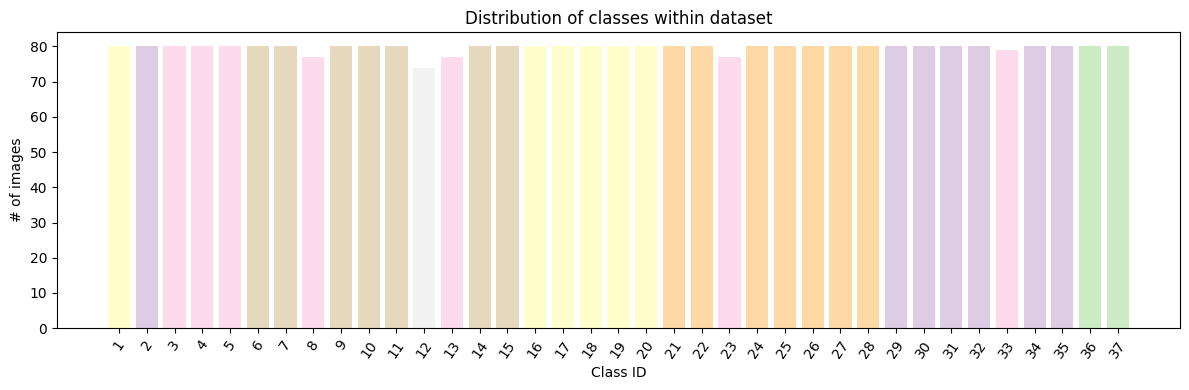

In [ ]:
image_class_distribution(train_df)

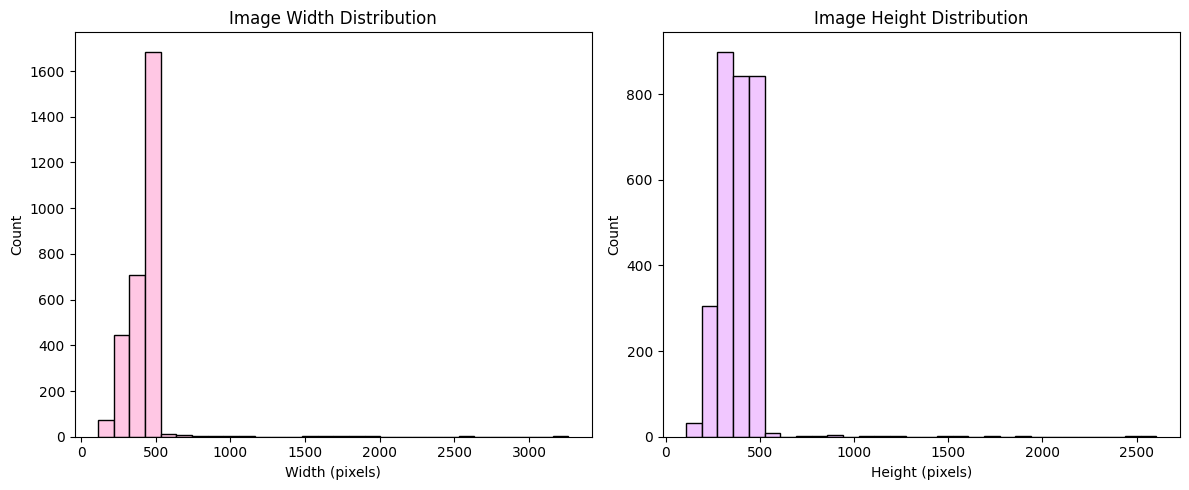

In [ ]:
image_size_distribution(train_df)

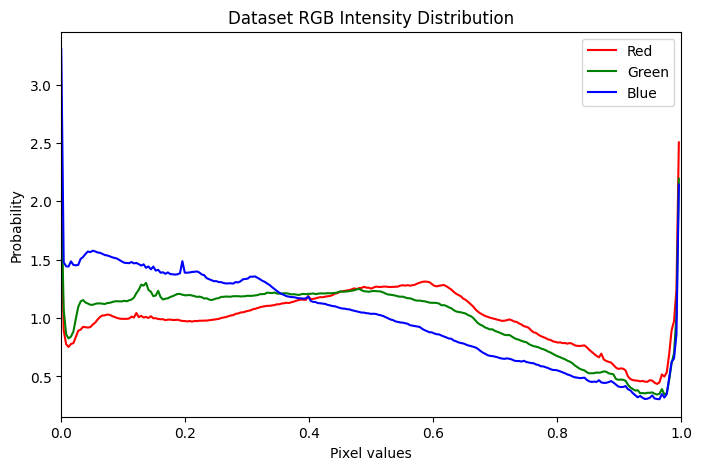

In [ ]:
image_pixel_intensities(train_df, sample_limit=1000, normalize=True)

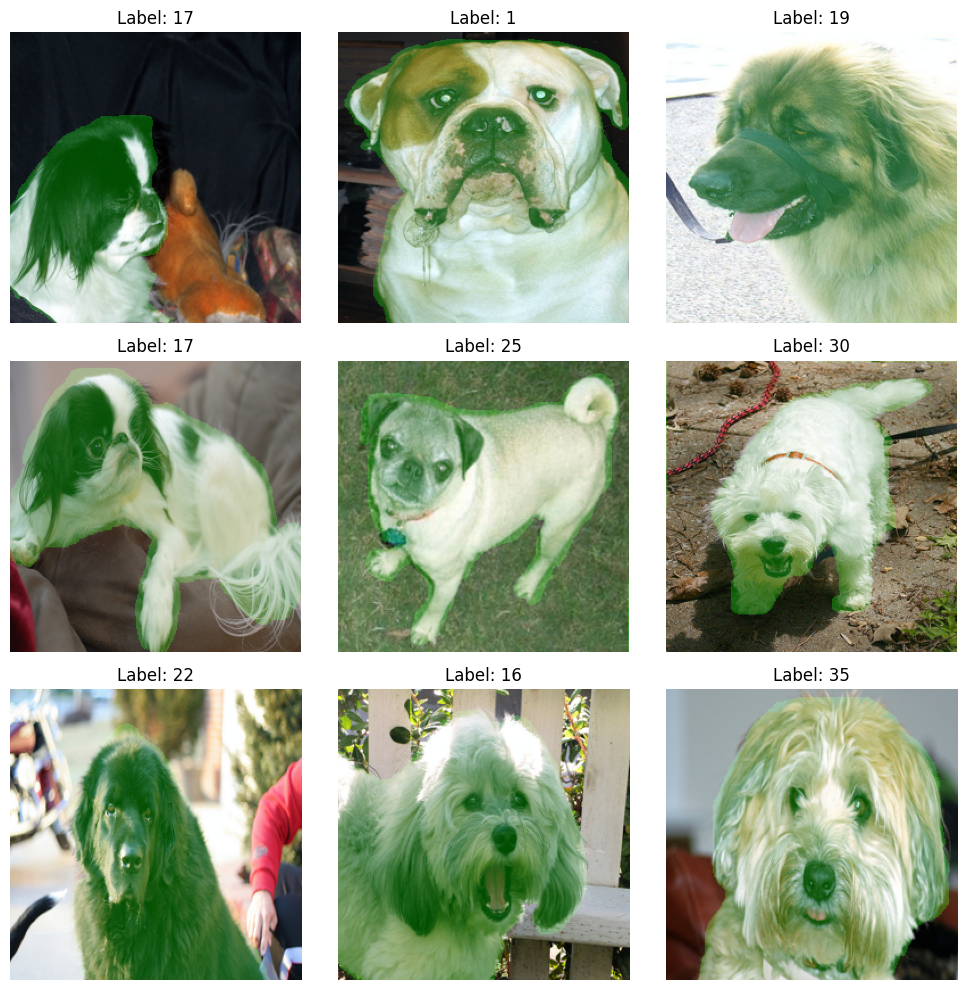

In [ ]:
show_random_images(train_dataset)

# **Segmentation**

## Evaluation Metics

### **Dice Loss**

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, epsilon=1.):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)  # raw logits to probabilities

        preds_flat = preds.view(preds.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (preds_flat * targets_flat).sum(dim=1)
        denom = preds_flat.sum(dim=1) + targets_flat.sum(dim=1)
        dice_score = (2.0 * intersection + self.epsilon) / (denom + self.epsilon)
        dice_loss = 1 - dice_score

        return dice_loss.mean()

### **IoU**

In [ ]:
def calculate_iou(y_pred, y_true, threshold=0.5, eps=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > threshold).float() #making it binaray

    y_pred = y_pred.view(y_pred.shape[0], -1)
    y_true = y_true.view(y_true.shape[0], -1)

    intersection = (y_pred * y_true).sum(dim = 1)
    union = y_pred.sum(dim = 1) + y_true.sum(dim = 1) - intersection

    # Compute IoU
    iou = (intersection + eps) / (union + eps)
    return iou.mean()

Additional Metrics

In [ ]:
def dice_score_batch(seg_logits, seg_targets, eps=1e-6):
    seg_preds = (torch.sigmoid(seg_logits) > 0.5).float()
    intersection = (seg_preds * seg_targets).sum(dim=(1, 2, 3))
    denom = seg_preds.sum(dim=(1, 2, 3)) + seg_targets.sum(dim=(1, 2, 3))
    return (2.0 * intersection + eps) / (denom + eps)


def iou_score_batch(seg_logits, seg_targets, eps=1e-6):
    seg_preds = (torch.sigmoid(seg_logits) > 0.5).bool()
    seg_targets = seg_targets.bool()

    intersection = (seg_preds & seg_targets).sum(dim=(1, 2, 3)).float()
    union = (seg_preds | seg_targets).sum(dim=(1, 2, 3)).float()

    return (intersection + eps) / (union + eps)


def pixel_accuracy_batch(seg_logits, seg_targets, threshold=0.5):
    seg_preds = (torch.sigmoid(seg_logits) > threshold).float()
    correct = (seg_preds == seg_targets).float()
    return correct.mean(dim=(1, 2, 3))


def mean_iou_binary(seg_logits, seg_targets, threshold=0.5, eps=1e-6):
    seg_preds = (torch.sigmoid(seg_logits) > threshold).bool()
    seg_targets = seg_targets.bool()

    # Foreground (pet) IoU
    fg_intersection = (seg_preds & seg_targets).sum().float()
    fg_union = (seg_preds | seg_targets).sum().float()
    iou_fg = (fg_intersection + eps) / (fg_union + eps)

    # Background IoU
    bg_preds = ~seg_preds
    bg_targets = ~seg_targets
    bg_intersection = (bg_preds & bg_targets).sum().float()
    bg_union = (bg_preds | bg_targets).sum().float()
    iou_bg = (bg_intersection + eps) / (bg_union + eps)

    miou = (iou_fg + iou_bg) / 2

    return miou.item(), iou_bg.item(), iou_fg.item()

## Base U-Net

The final Unet architecture:


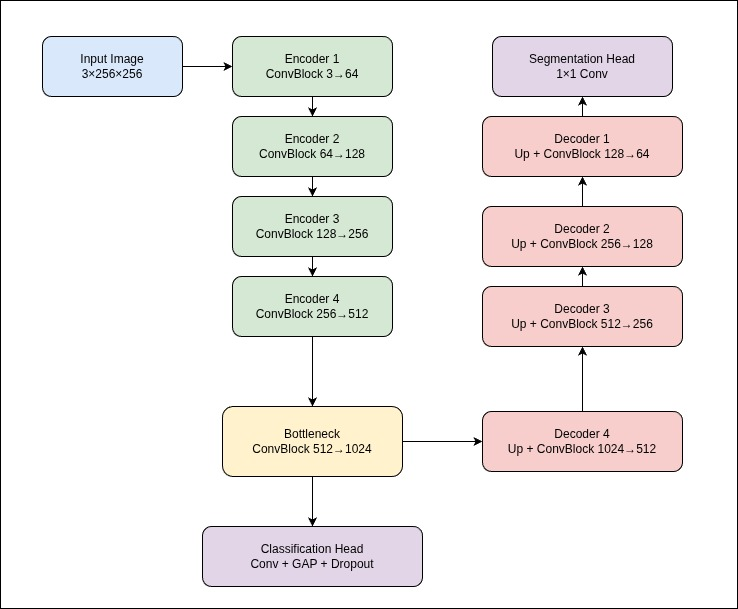



### **Defining Layers**

>## **Convolutional Layer**

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

>## **Encoder**

In [ ]:
class UNetEncoder(nn.Module):
    def __init__(self, in_channels, first_out_channel=16):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, first_out_channel)
        self.enc2 = ConvBlock(first_out_channel, first_out_channel*2)
        self.enc3 = ConvBlock(first_out_channel*2, first_out_channel*4)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        #pooling layer can be reused as there are no learnable parameters

    def forward(self, x):
        x1 = self.enc1(x)              # 16 channels x 600
        x2 = self.enc2(self.pool(x1))  # 32 channels x 300
        x3 = self.enc3(self.pool(x2))  # 64 channels x 150

        return x1, x2, x3

>## **Bottleneck Layer**

In [ ]:
class UNetBottleneck(nn.Module):
  def __init__(self, in_channels):
    super().__init__()

    self.enc = ConvBlock(in_channels, in_channels*2)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    return self.enc(self.pool(x))

>## **Decoder**

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(2*out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        #the 2*out_channels in the first conv is used to accomodate the skip connection

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

In [ ]:
class UNetDecoder(nn.Module):
    def __init__(self, in_channels = 128):
        super().__init__()

        self.decode1 = DecoderBlock(in_channels=in_channels, out_channels=in_channels//2)
        self.decode2 = DecoderBlock(in_channels=in_channels//2, out_channels=in_channels//4)
        self.decode3 = DecoderBlock(in_channels=in_channels//4, out_channels=in_channels//8)

        self.final_conv = nn.Conv2d(in_channels//8, 1, kernel_size=1)  # Output 1 channel for binary segmentation

    def forward(self, x4, x3, x2, x1):
        x3 = self.decode1(x4, x3) # 64 channels x 150
        x2 = self.decode2(x3, x2)  # 32 channels x 300
        x1 = self.decode3(x2, x1)  # 16 channels x 600
        x = self.final_conv(x1).squeeze(1) #1 channel x 600
        return x

### **U-Net Model**

In [ ]:
class UNet(nn.Module):
    def __init__(self,
                 seg_output_channels=1,
                 num_pet_classes=37,
                 base_feature_channels=64):
        super().__init__()
        b = base_feature_channels

        # Encoder
        self.enc1 = ConvBlock(3, b)
        self.enc2 = ConvBlock(b, 2*b)
        self.enc3 = ConvBlock(2*b, 4*b)
        self.enc4 = ConvBlock(4*b, 8*b)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = ConvBlock(8*b, 16*b)

        # Decoder
        self.dec4 = DecoderBlock(16*b, 8*b)
        self.dec3 = DecoderBlock( 8*b, 4*b)
        self.dec2 = DecoderBlock( 4*b, 2*b)
        self.dec1 = DecoderBlock( 2*b, b)

        # Heads
        self.seg_head = nn.Conv2d(b, seg_output_channels, kernel_size=1)
        self.cls_head = nn.Sequential(
            nn.Conv2d(16*b, 8*b, kernel_size=3, padding=1),
            nn.BatchNorm2d(8*b),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(8*b, num_pet_classes)
        )

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)                  # b   × 256 × 256
        x2 = self.enc2(self.pool(x1))      # 2b  × 128 × 128
        x3 = self.enc3(self.pool(x2))      # 4b  × 64  × 64
        x4 = self.enc4(self.pool(x3))      # 8b  × 32  × 32

        # Bottleneck
        x5 = self.bottleneck(self.pool(x4))  # 16b × 16  × 16

        # Heads
        cls_out = self.cls_head(x5)           # (B, num_pet_classes)

        # Decoder
        d4 = self.dec4(x5, x4)             # 8b  × 32  × 32
        d3 = self.dec3(d4, x3)             # 4b  × 64  × 64
        d2 = self.dec2(d3, x2)             # 2b  × 128 × 128
        d1 = self.dec1(d2, x1)             # b   × 256 × 256

        seg_out = self.seg_head(d1)         # seg_output_channels × 256 × 256

        return seg_out, cls_out

In [ ]:
# Instantiate base U-Net for 37 Oxford Pets classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_unet = UNet(seg_output_channels=1,
    num_pet_classes=num_classes,
    base_feature_channels=64
)

print("Pets MultiTask U-Net Architecture:")
print(model_unet)

try:
    from torchsummary import summary
    summary(model_unet, (3, 256, 256), device="cpu")
except ImportError:
    print("torchsummary not installed – skipping summary.")

device = "cuda" if torch.cuda.is_available() else "cpu"
model_unet  = model_unet.to(device)


model_unet = UNet().to(device)

Pets MultiTask U-Net Architecture:
UNet(
  (enc1): ConvBlock(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout2d(p=0.1, inplace=False)
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout2d(p=0.1, inplace=False)
      (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

### **Training**

Help to visualize the:
* Original image
* Ground-truth mask
* Predicted mask
* Overlays on the image

In [ ]:
def render_multitask_result_grid(image_tensor,mask_tensor,segmentation_logits,predicted_class,true_class,sample_iou,save_path=None):

    img_np = (image_tensor.detach().cpu().permute(1, 2, 0).numpy())
    img_np = (img_np * 255).astype(np.uint8)


    gt_mask_np = (mask_tensor.detach().cpu().squeeze(0).numpy())
    gt_mask_np = (gt_mask_np * 255).astype(np.uint8)


    if isinstance(segmentation_logits, torch.Tensor):
        pred_mask = torch.sigmoid(segmentation_logits)
        pred_mask = (pred_mask > 0.5).float()
        pred_mask_np = (pred_mask.detach().cpu().squeeze().numpy())
    else:
        pred_mask_np = segmentation_logits

    pred_mask_np = (pred_mask_np * 255).astype(np.uint8)

    gt_colormap = cv2.applyColorMap(gt_mask_np, cv2.COLORMAP_JET)
    pred_colormap = cv2.applyColorMap(pred_mask_np, cv2.COLORMAP_JET)

    gt_overlay = cv2.addWeighted(img_np, 0.7, gt_colormap, 0.3, 0)
    pred_overlay = cv2.addWeighted(img_np, 0.7, pred_colormap, 0.3, 0)

    gt_mask_rgb = cv2.cvtColor(gt_mask_np, cv2.COLOR_GRAY2RGB)
    pred_mask_rgb = cv2.cvtColor(pred_mask_np, cv2.COLOR_GRAY2RGB)

    top_row = np.hstack([img_np, gt_mask_rgb, gt_overlay])
    bottom_row = np.hstack([img_np, pred_mask_rgb, pred_overlay])

    grid_image = np.vstack([top_row, bottom_row])

    title_text = (
        f"Cls Correct: {int(predicted_class == true_class)} | "
        f"IoU: {sample_iou:.3f} | "
        f"Pred: {predicted_class} | True: {true_class}"
    )

    cv2.putText(
        grid_image,
        title_text,
        (5, 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    if save_path is not None:
        cv2.imwrite(save_path,cv2.cvtColor(grid_image, cv2.COLOR_RGB2BGR))

    return grid_image


In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=51,
    lr=1e-3,
    save_path="best_model.pth",
    resume_checkpoint=None,
    output_dir="training_outputs"
):
    os.makedirs(output_dir, exist_ok=True)
    model.to(device)

    bce_loss = nn.BCEWithLogitsLoss()
    segmentation_loss_fn = DiceLoss()
    classification_loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_iou": [], "val_iou": [],
        "train_dice": [], "val_dice": [],
        "train_cls_acc": [], "val_cls_acc": []
    }

    start_epoch = 0
    best_val_loss = float("inf")

    if resume_checkpoint is not None and os.path.exists(resume_checkpoint):
        checkpoint = torch.load(resume_checkpoint, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        history = checkpoint["history"]
        start_epoch = checkpoint["epoch"] + 1
        best_val_loss = checkpoint["best_val_loss"]
        print(f"Resumed training from epoch {start_epoch}")

    for epoch in range(start_epoch, num_epochs):
        print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")

        for phase in ["train", "val"]:
            is_train = phase == "train"
            model.train() if is_train else model.eval()

            running_loss = 0.0
            running_iou = 0.0
            running_dice = 0.0
            running_correct = 0
            total_samples = 0

            loader = train_loader if is_train else val_loader

            for images, masks, labels in loader:
                images = images.to(device)
                masks = masks.to(device)
                labels = labels.to(device).view(-1).long()

                optimizer.zero_grad()

                with torch.set_grad_enabled(is_train):
                    seg_logits, cls_logits = model(images)

                    seg_loss = bce_loss(seg_logits, masks) + segmentation_loss_fn(seg_logits, masks)
                    cls_loss = classification_loss_fn(cls_logits, labels)

                    loss = 0.7 * seg_loss + 0.3 * cls_loss
                    loss = loss.mean()

                    if is_train:
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                batch_size = images.size(0)

                iou_vals = iou_score_batch(seg_logits, masks)
                dice_vals = dice_score_batch(seg_logits, masks)

                running_iou += iou_vals.mean().item() * batch_size
                running_dice += dice_vals.mean().item() * batch_size

                preds_cls = cls_logits.argmax(dim=1)
                running_correct += (preds_cls == labels).sum().item()

                running_loss += loss.item() * batch_size
                total_samples += batch_size

            epoch_loss = running_loss / total_samples
            epoch_iou = running_iou / total_samples
            epoch_dice = running_dice / total_samples
            epoch_acc = running_correct / total_samples

            print(
                f"{phase} | Loss: {epoch_loss:.4f} | "
                f"IoU: {epoch_iou:.4f} | "
                f"Dice: {epoch_dice:.4f} | "
                f"Cls Acc: {epoch_acc:.4f}"
            )

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_iou"].append(epoch_iou)
            history[f"{phase}_dice"].append(epoch_dice)
            history[f"{phase}_cls_acc"].append(epoch_acc)

            if not is_train:
                scheduler.step()

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss

                    checkpoint = {
                        "epoch": epoch,
                        "model_state": model.state_dict(),
                        "optimizer_state": optimizer.state_dict(),
                        "history": history,
                        "best_val_loss": best_val_loss
                    }

                    torch.save(checkpoint, os.path.join(output_dir, "best_checkpoint.pth"))
                    torch.save(model.state_dict(), save_path)
                    print("Saved best model checkpoint")

    return history

In [ ]:
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_iou"], label="Train")
    plt.plot(epochs, history["val_iou"], label="Val")
    plt.title("IoU")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_cls_acc"], label="Train")
    plt.plot(epochs, history["val_cls_acc"], label="Val")
    plt.title("Classification Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# import torch

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# print("=" * 50)
# print("GPU DIAGNOSTIC CHECK")
# print("=" * 50)
# print(f"CUDA Available: {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     print(f"GPU Name: {torch.cuda.get_device_name(0)}")
#     print(f"GPU Memory (GB): {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
#     print(f"Device: {device}")
#     if "model_unet" in globals():
#         print(f"Model is on device: {next(model_unet.parameters()).device}")
# else:
#     print("CUDA NOT AVAILABLE - Training will run on CPU.")
#     print(f"Device: {device}")
# print("=" * 50)

Training on device: cuda:0
GPU: Tesla T4

=== Epoch 1/51 ===
train | Loss: 1.7846 | IoU: 0.5304 | Dice: 0.6742 | Cls Acc: 0.0312
val | Loss: 1.6483 | IoU: 0.6185 | Dice: 0.7521 | Cls Acc: 0.0326
Saved best model checkpoint

=== Epoch 2/51 ===
train | Loss: 1.6294 | IoU: 0.6133 | Dice: 0.7468 | Cls Acc: 0.0445
val | Loss: 1.6066 | IoU: 0.6174 | Dice: 0.7499 | Cls Acc: 0.0489
Saved best model checkpoint

=== Epoch 3/51 ===
train | Loss: 1.5726 | IoU: 0.6432 | Dice: 0.7703 | Cls Acc: 0.0445
val | Loss: 1.5463 | IoU: 0.6519 | Dice: 0.7777 | Cls Acc: 0.0639
Saved best model checkpoint

=== Epoch 4/51 ===
train | Loss: 1.5140 | IoU: 0.6647 | Dice: 0.7869 | Cls Acc: 0.0639
val | Loss: 1.4377 | IoU: 0.6853 | Dice: 0.8039 | Cls Acc: 0.0883
Saved best model checkpoint

=== Epoch 5/51 ===
train | Loss: 1.4732 | IoU: 0.6725 | Dice: 0.7927 | Cls Acc: 0.0880
val | Loss: 1.4213 | IoU: 0.6719 | Dice: 0.7934 | Cls Acc: 0.1168
Saved best model checkpoint

=== Epoch 6/51 ===
train | Loss: 1.4455 | IoU: 0

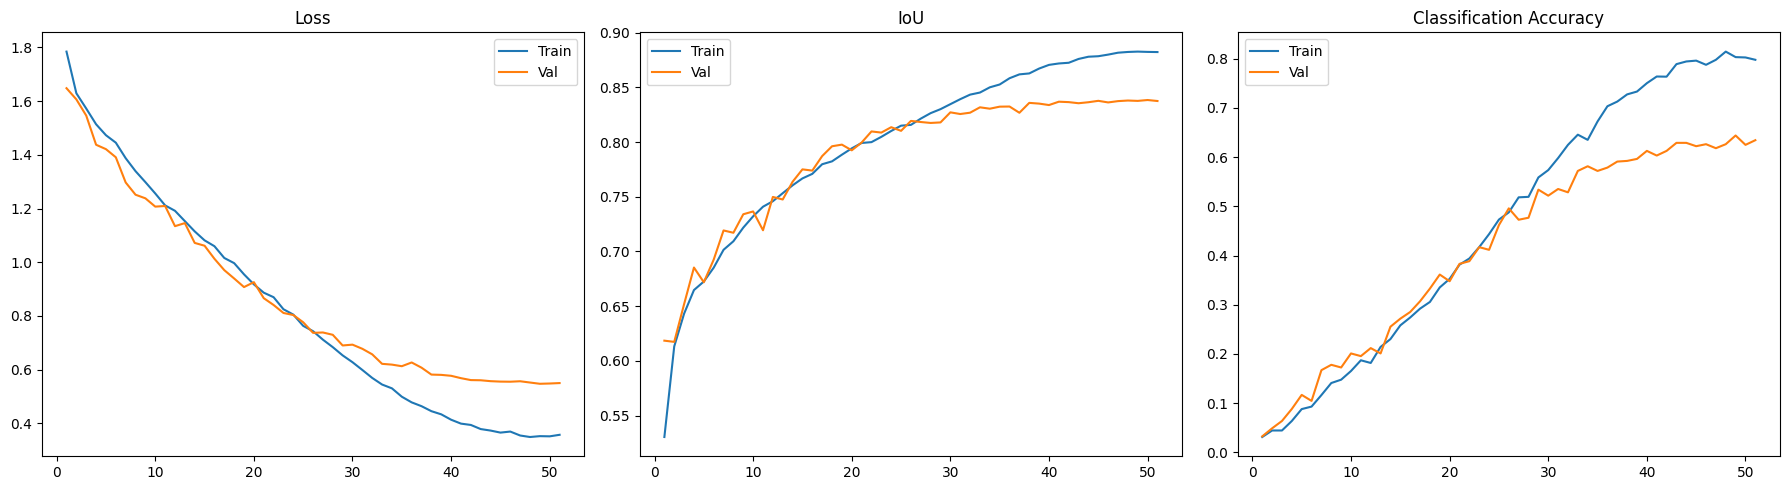

In [ ]:
# Ensure we always use the active GPU when available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_unet = model_unet.to(device)

print(f"Training on device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

history_unet = train_model(
    model_unet,
    train_loader,
    val_loader,
    device,
    save_path=f"{unet_dir}/best_model.pth",
    resume_checkpoint=f"{unet_dir}/checkpoints/last_checkpoint.pth",
    output_dir=f"{unet_dir}/checkpoints")
plot_training_curves(history_unet)

Observation:

training accuracy is higher than validation, model is over fitting.

we can try creating more training data using data augmentation

### **Testing**

In [ ]:
def plot_classification_summary(cls_metrics,title="Classification Performance"):


    metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
    metric_values = [
        cls_metrics["acc"],
        cls_metrics["precision"],
        cls_metrics["recall"],
        cls_metrics["f1"]]

    plt.figure(figsize=(6, 5))
    bars = plt.bar(
        metric_names,
        metric_values,
        color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])

    for bar, value in zip(bars, metric_values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{value:.3f}",
            ha="center",
            fontsize=11
        )

    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


In [ ]:
def evaluate_model(
    model,
    data_loader,
    device,
    class_labels=None,
    show_per_class_metrics=True
):
    model.eval()

    dice_scores = []
    iou_scores = []
    pixel_acc_scores = []

    all_cls_preds = []
    all_cls_targets = []

    all_seg_logits = []
    all_seg_targets = []

    with torch.no_grad():
        # unpacks 3 values
        for seg_imgs, seg_masks, cls_targets in tqdm(
            data_loader, desc="Evaluating", leave=True
        ):
            seg_imgs = seg_imgs.to(device)
            seg_masks = seg_masks.to(device)
            cls_targets = cls_targets.to(device).view(-1).long()  # consistent with train_model

            seg_logits, cls_logits = model(seg_imgs)

            dice_vals = dice_score_batch(seg_logits, seg_masks)
            iou_vals = iou_score_batch(seg_logits, seg_masks)
            pix_vals = pixel_accuracy_batch(seg_logits, seg_masks)

            dice_scores.extend(dice_vals.cpu().tolist())
            iou_scores.extend(iou_vals.cpu().tolist())
            pixel_acc_scores.extend(pix_vals.cpu().tolist())

            cls_predictions = cls_logits.argmax(dim=1)
            all_cls_preds.extend(cls_predictions.cpu().tolist())
            all_cls_targets.extend(cls_targets.cpu().tolist())

            all_seg_logits.append(seg_logits.cpu())
            all_seg_targets.append(seg_masks.cpu())

    mean_dice = float(np.mean(dice_scores))
    mean_iou_image = float(np.mean(iou_scores))
    mean_pixel_acc = float(np.mean(pixel_acc_scores))

    all_seg_logits = torch.cat(all_seg_logits, dim=0)
    all_seg_targets = torch.cat(all_seg_targets, dim=0)

    miou, iou_bg, iou_fg = mean_iou_binary(all_seg_logits, all_seg_targets)  # now defined above

    cls_accuracy = accuracy_score(all_cls_targets, all_cls_preds)

    prec_pc, rec_pc, f1_pc, _ = precision_recall_fscore_support(
        all_cls_targets,
        all_cls_preds,
        average=None,
        zero_division=0
    )

    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        all_cls_targets,
        all_cls_preds,
        average="weighted",
        zero_division=0
    )

    print(
        f"Segmentation → "
        f"Dice: {mean_dice:.4f} | "
        f"IoU(image-mean): {mean_iou_image:.4f} | "
        f"mIoU: {miou:.4f} | "
        f"IoU_bg: {iou_bg:.4f} | "
        f"IoU_fg: {iou_fg:.4f} | "
        f"PixelAcc: {mean_pixel_acc:.4f}"
    )
    print(f"Classification → Accuracy: {cls_accuracy:.4f}")

    if class_labels is not None:
        print("\nDetailed Classification Report:")
        print(
            classification_report(
                all_cls_targets,
                all_cls_preds,
                target_names=class_labels,
                digits=4
            )
        )

        cm = confusion_matrix(all_cls_targets, all_cls_preds)
        plt.figure(figsize=(20, 16))  # figure for 37 classes
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels
        )
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("Classification Confusion Matrix")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    if show_per_class_metrics and class_labels is not None:
        x = np.arange(len(class_labels))
        width = 0.25

        plt.figure(figsize=(20, 6))  # figure for 37 classes
        plt.bar(x - width, prec_pc, width, label="Precision")
        plt.bar(x, rec_pc, width, label="Recall", alpha=0.7)
        plt.bar(x + width, f1_pc, width, label="F1-score", alpha=0.4)
        plt.xticks(x, class_labels, rotation=90)
        plt.ylim(0, 1)
        plt.ylabel("Score")
        plt.title("Per-Class Classification Metrics")
        plt.legend()
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    return {
        "segmentation": {
            "dice": mean_dice,
            "iou_image_mean": mean_iou_image,
            "miou": miou,
            "iou_background": iou_bg,
            "iou_foreground": iou_fg,
            "pixel_accuracy": mean_pixel_acc
        },
        "classification": {
            "accuracy": cls_accuracy,
            "precision": prec_w,
            "recall": rec_w,
            "f1": f1_w,
            "per_class": {
                "precision": prec_pc,
                "recall": rec_pc,
                "f1": f1_pc
            }
        }
    }

Evaluating: 100%|██████████| 230/230 [01:19<00:00,  2.91it/s]


Segmentation → Dice: 0.9064 | IoU(image-mean): 0.8394 | mIoU: 0.8641 | IoU_bg: 0.8846 | IoU_fg: 0.8437 | PixelAcc: 0.9289
Classification → Accuracy: 0.5407

Detailed Classification Report:
                            precision    recall  f1-score   support

                Abyssinian     0.4109    0.5408    0.4670        98
          american_bulldog     0.4252    0.5400    0.4758       100
 american_pit_bull_terrier     0.3000    0.1800    0.2250       100
              basset_hound     0.4912    0.5600    0.5234       100
                    beagle     0.4222    0.3800    0.4000       100
                    Bengal     0.6200    0.6200    0.6200       100
                    Birman     0.5596    0.6100    0.5837       100
                    Bombay     0.6176    0.7159    0.6632        88
                     boxer     0.3478    0.4040    0.3738        99
         British_Shorthair     0.5619    0.5900    0.5756       100
                 chihuahua     0.3968    0.2500    0.3067     

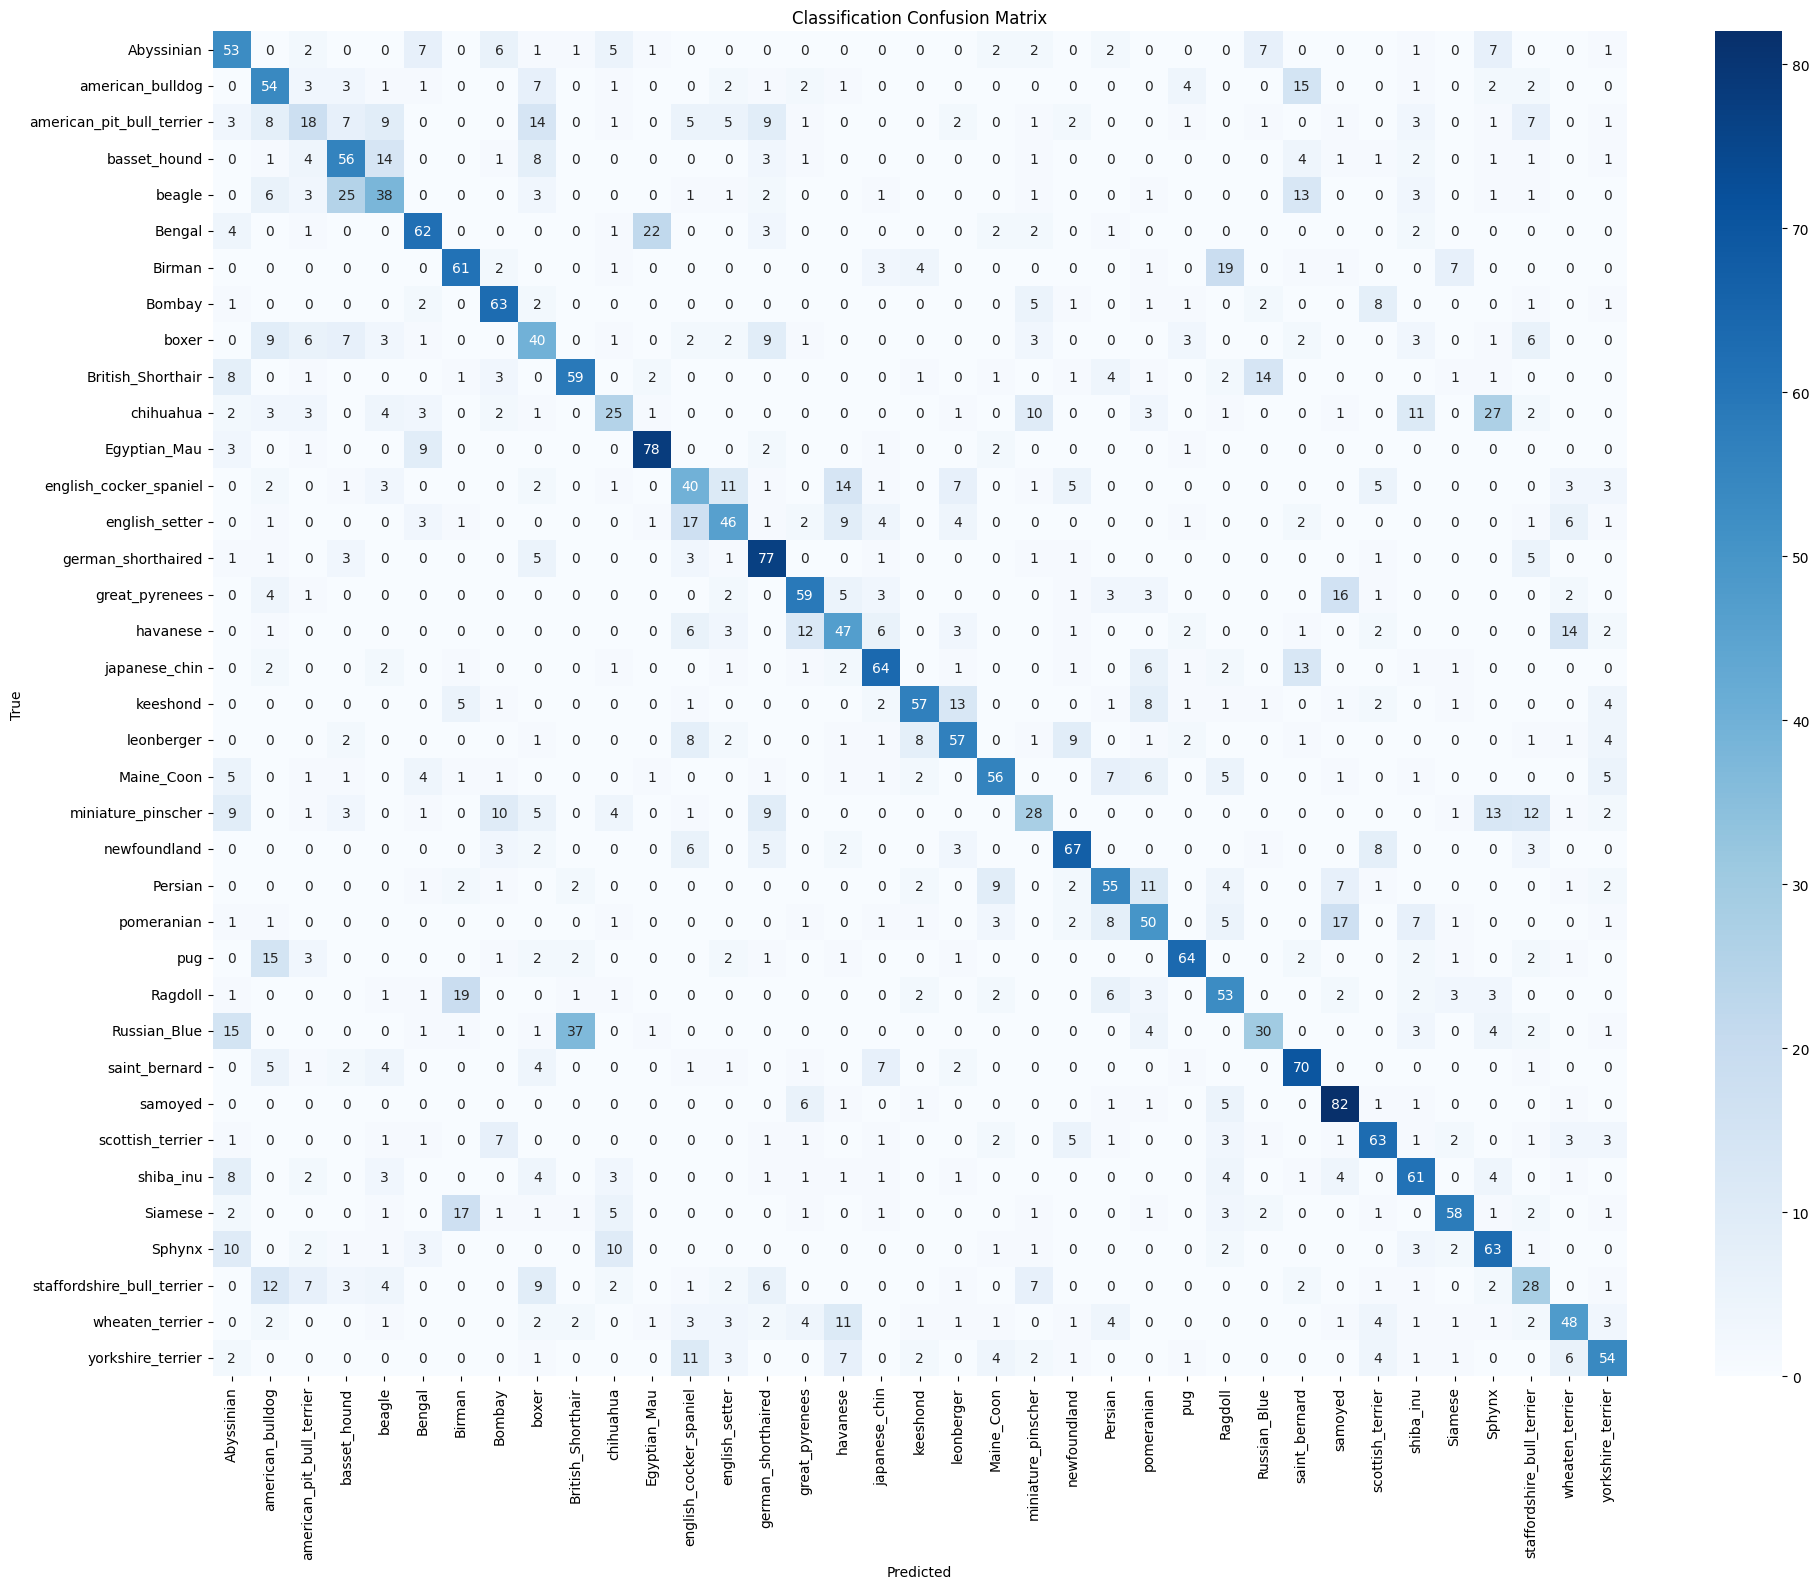

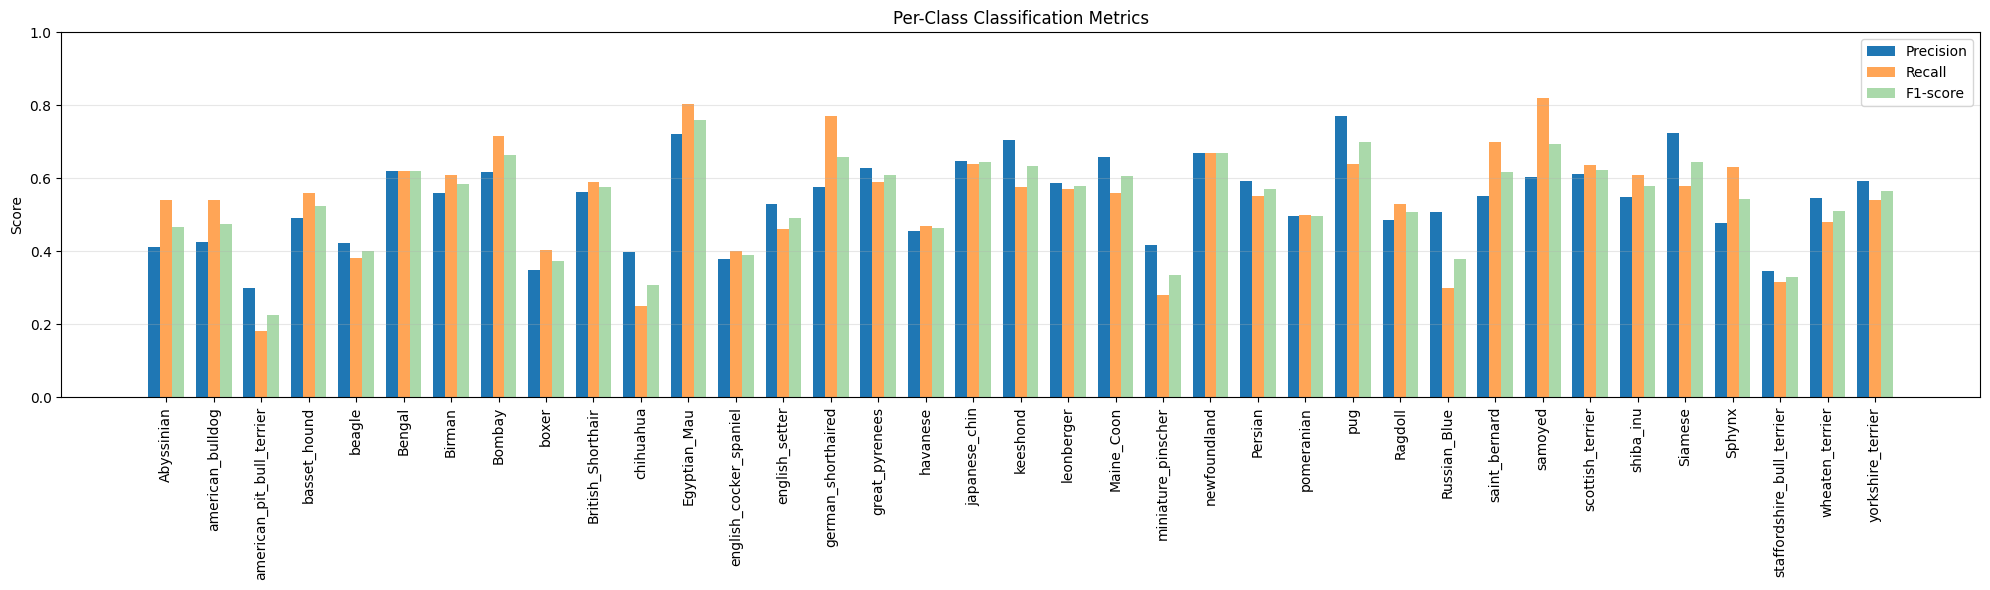

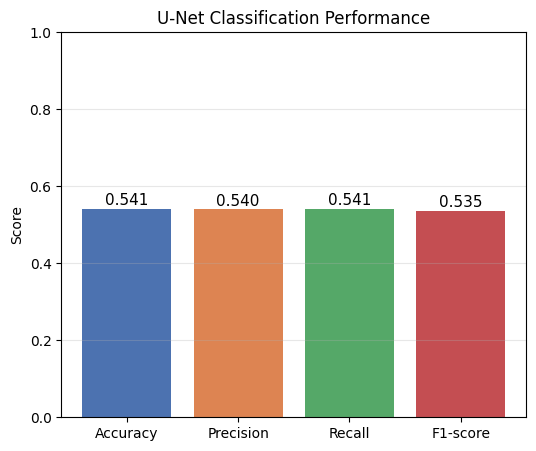

In [ ]:
# Load best weights from training
# model_unet.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
# model_unet = model_unet.to(device)  # then move to GPU after

checkpoint = torch.load(
    f"{unet_dir}/checkpoints/best_checkpoint.pth",
    map_location=device
)
model_unet.load_state_dict(checkpoint["model_state"])
model_unet.to(device)

# Switch to evaluation mode
model_unet.eval()

# Run test evaluation
metrics_unet = evaluate_model(
    model=model_unet,
    data_loader=test_loader,
    device=device,
    class_labels=class_labels,
    show_per_class_metrics=True
)

# Map to the expected key names
cls_metrics = {
    "acc":       metrics_unet["classification"]["accuracy"],
    "precision": metrics_unet["classification"]["precision"],
    "recall":    metrics_unet["classification"]["recall"],
    "f1":        metrics_unet["classification"]["f1"]
}

plot_classification_summary(cls_metrics, title="U-Net Classification Performance")

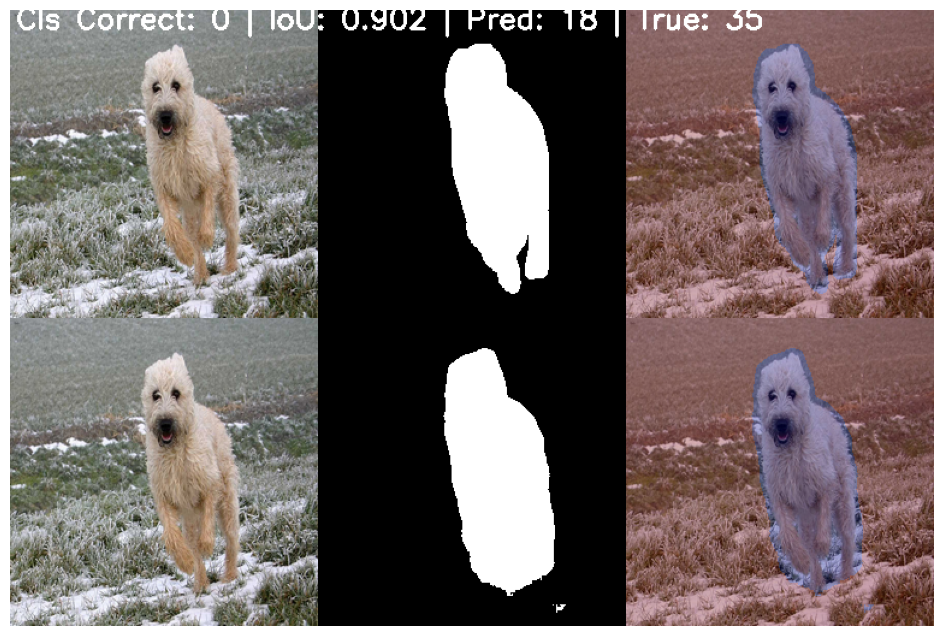

In [ ]:
model_unet.eval()

idx = torch.randint(0, len(test_dataset), (1,)).item()
image, mask, label = test_dataset[idx]

image = image.to(device)
mask  = mask.to(device)

with torch.no_grad():
    seg_logits, cls_logits = model_unet(image.unsqueeze(0))

predicted_class = cls_logits.argmax(dim=1).item()
iou = iou_score_batch(seg_logits, mask.unsqueeze(0)).item()

# Denormalize so colors look correct
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
image_display = (image * std + mean).clamp(0, 1)

grid = render_multitask_result_grid(
    image_tensor        = image_display,
    mask_tensor         = mask,
    segmentation_logits = seg_logits.squeeze(0),
    predicted_class     = predicted_class,
    true_class          = label,
    sample_iou          = iou,
    save_path           = "result_unet.png"
)

plt.figure(figsize=(12, 8))
plt.imshow(grid)
plt.axis("off")
plt.show()

### Presentation

In [ ]:
def predict_by_index(model, dataset, index, device, class_labels):
    model.eval()

    img_tensor, gt_mask, label = dataset[index]

    with torch.no_grad():
        seg_logits, cls_logits = model(img_tensor.unsqueeze(0).to(device))

    # Predicted mask
    seg_pred = (torch.sigmoid(seg_logits)[0, 0].cpu().numpy() > 0.5).astype(np.uint8)

    # Ground truth mask
    gt_mask_np = gt_mask.squeeze().cpu().numpy().astype(np.uint8)

    # IoU
    intersection = np.logical_and(seg_pred, gt_mask_np).sum()
    union        = np.logical_or(seg_pred, gt_mask_np).sum()
    iou          = intersection / (union + 1e-6)

    # Denormalize image for display
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)
    img_np = (img_np * 255).astype(np.uint8)

    # Overlays
    true_overlay = img_np.copy()
    true_overlay[gt_mask_np == 1] = (
        true_overlay[gt_mask_np == 1] * 0.5 + np.array([255, 0, 0]) * 0.5
    ).astype(np.uint8)

    pred_overlay = img_np.copy()
    pred_overlay[seg_pred == 1] = (
        pred_overlay[seg_pred == 1] * 0.5 + np.array([0, 255, 0]) * 0.5
    ).astype(np.uint8)

    # Class names
    true_class = class_labels[label.item()]
    pred_class = class_labels[cls_logits.argmax(dim=1).item()]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    axes[0].imshow(img_np);       axes[0].set_title("Original image");         axes[0].axis("off")
    axes[1].imshow(true_overlay); axes[1].set_title("Image + True mask overlay"); axes[1].axis("off")
    axes[2].imshow(pred_overlay); axes[2].set_title("Image + Predict mask overlay"); axes[2].axis("off")

    fig.suptitle(
        f'Original class - "{true_class}"\n'
        f'Predicted class - "{pred_class}"\n'
        f'IoU - {iou * 100:.1f}%',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

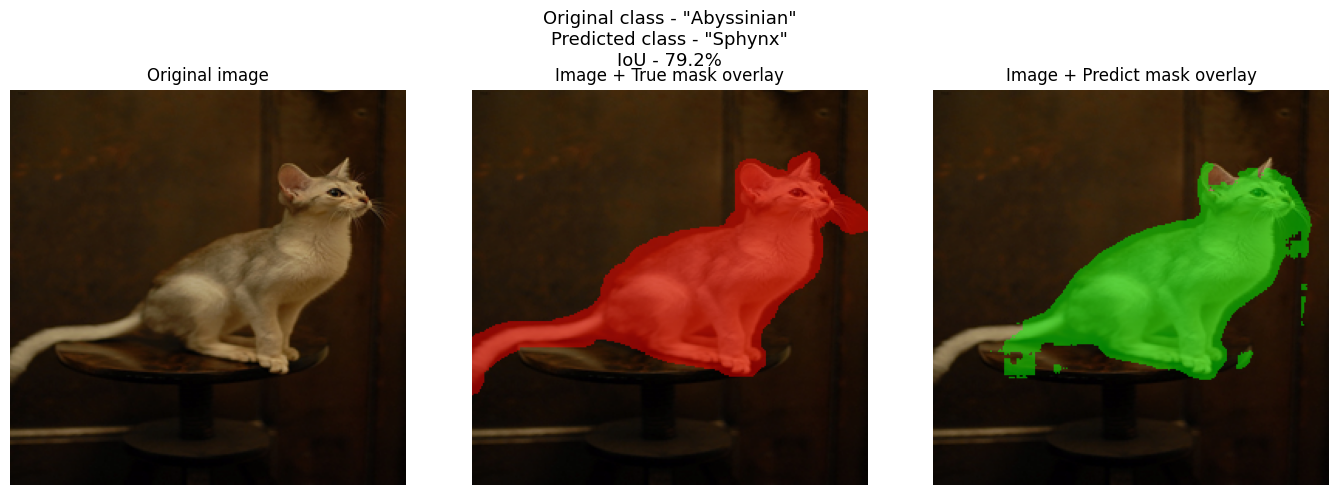

In [ ]:
# Visual Representaion
predict_by_index(model_unet, test_dataset, index=42, device=device, class_labels=class_labels)


## Attention U-Net

attention u-net architechture

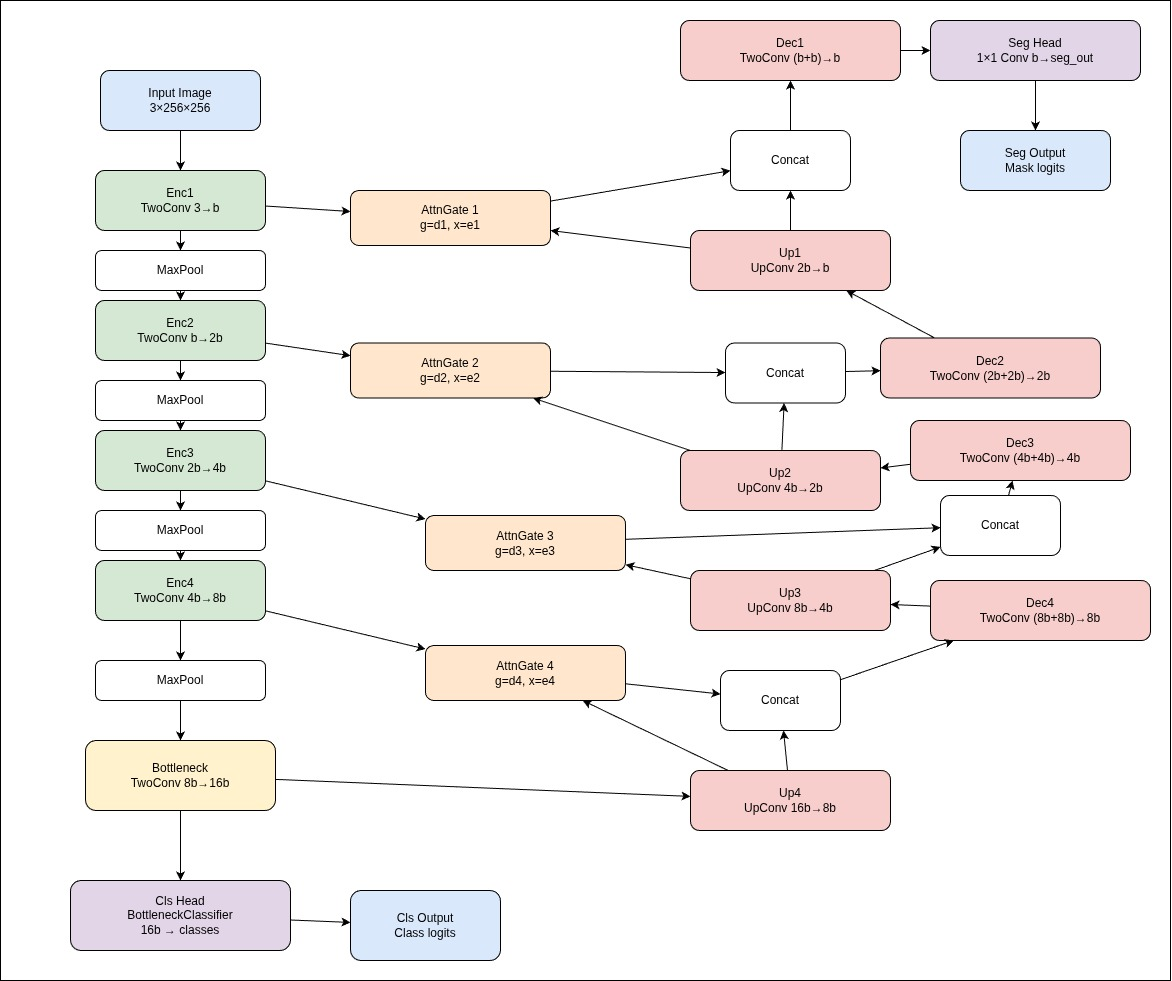

### Attention Gate

In [ ]:
def safe_group_tensor(channels, max_groups=8):
    channels = int(channels)
    max_groups = int(max_groups)

    for g in range(min(max_groups, channels), 0, -1):
        if channels % g == 0:
            return g
    return 1

class AttentionGate(nn.Module):
    def __init__(self, dec_ch, enc_ch, inter_ch):
        super().__init__()

        g_groups = safe_group_tensor(inter_ch, 8)
        x_groups = safe_group_tensor(inter_ch, 8)

        self.g_proj = nn.Sequential(
            nn.Conv2d(dec_ch, inter_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(g_groups, inter_ch),
            nn.ReLU(inplace=True),
        )
        self.x_proj = nn.Sequential(
            nn.Conv2d(enc_ch, inter_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(x_groups, inter_ch),
            nn.ReLU(inplace=True),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=True),
            nn.Sigmoid()
        )
        self.act = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, g, x):
        g1 = self.g_proj(g)
        x1 = self.x_proj(x)
        a = self.psi(self.act(g1 + x1))
        return x * a + x


In [ ]:
class TwoConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class BottleneckClassifier(nn.Module):
    def __init__(self, in_ch, num_classes=37, hidden_ch=None, dropout=0.3):
        super().__init__()
        if hidden_ch is None:
            hidden_ch = in_ch // 2

        self.c1 = nn.Conv2d(in_ch, hidden_ch, kernel_size=3, padding=1)
        self.b1 = nn.BatchNorm2d(hidden_ch)

        self.c2 = nn.Conv2d(hidden_ch, hidden_ch // 2, kernel_size=3, padding=1)
        self.b2 = nn.BatchNorm2d(hidden_ch // 2)

        self.c3 = nn.Conv2d(hidden_ch // 2, num_classes, kernel_size=3, padding=1)

        self.drop = nn.Dropout(dropout)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = F.relu(self.b1(self.c1(x)))
        x = F.relu(self.b2(self.c2(x)))
        x = self.c3(x)
        x = self.pool(x).squeeze(-1).squeeze(-1)
        x = self.drop(x)
        return x


In [ ]:
class Attention_UNet(nn.Module):
    def __init__(self, seg_out_ch=1, cls_out_classes=4, base_ch=32):
        super().__init__()
        b = base_ch
        self.pool = nn.MaxPool2d(2)

        self.enc1 = TwoConv(3, b)
        self.enc2 = TwoConv(b, 2*b)
        self.enc3 = TwoConv(2*b, 4*b)
        self.enc4 = TwoConv(4*b, 8*b)
        self.bott = TwoConv(8*b, 16*b)

        self.up4 = nn.ConvTranspose2d(16*b, 8*b, kernel_size=2, stride=2)
        self.att4 = AttentionGate(dec_ch=8*b, enc_ch=8*b, inter_ch=4*b)
        self.dec4 = TwoConv(16*b, 8*b)

        self.up3 = nn.ConvTranspose2d(8*b, 4*b, kernel_size=2, stride=2)
        self.att3 = AttentionGate(dec_ch=4*b, enc_ch=4*b, inter_ch=2*b)
        self.dec3 = TwoConv(8*b, 4*b)

        self.up2 = nn.ConvTranspose2d(4*b, 2*b, kernel_size=2, stride=2)
        self.att2 = AttentionGate(dec_ch=2*b, enc_ch=2*b, inter_ch=b)
        self.dec2 = TwoConv(4*b, 2*b)

        self.up1 = nn.ConvTranspose2d(2*b, b, kernel_size=2, stride=2)
        self.att1 = AttentionGate(dec_ch=b, enc_ch=b, inter_ch=max(1, b//2))
        self.dec1 = TwoConv(2*b, b)

        self.seg_head = nn.Conv2d(b, seg_out_ch, kernel_size=1)
        self.cls_head = BottleneckClassifier(in_ch=16*b, num_classes=cls_out_classes)

    def forward(self, x_img, x_cls=None):
        e1 = self.enc1(x_img)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bott(self.pool(e4))

        d4 = self.up4(bn)
        e4a = self.att4(g=d4, x=e4)
        d4 = self.dec4(torch.cat([d4, e4a], dim=1))

        d3 = self.up3(d4)
        e3a = self.att3(g=d3, x=e3)
        d3 = self.dec3(torch.cat([d3, e3a], dim=1))

        d2 = self.up2(d3)
        e2a = self.att2(g=d2, x=e2)
        d2 = self.dec2(torch.cat([d2, e2a], dim=1))

        d1 = self.up1(d2)
        e1a = self.att1(g=d1, x=e1)
        d1 = self.dec1(torch.cat([d1, e1a], dim=1))

        seg_logits = self.seg_head(d1)
        cls_logits = self.cls_head(bn)

        return seg_logits, cls_logits


### Training, testing

In [ ]:
# Instantiate Attention U-Net for Oxford Pets
model_att_unet = Attention_UNet(
    seg_out_ch=1,
    cls_out_classes=num_classes,
    base_ch=32
).to(device)
print("Attention U-Net built. Classes:", num_classes)


Attention U-Net built. Classes: 37


Training on device: cuda:0
GPU: Tesla T4

=== Epoch 1/50 ===
train | Loss: 1.3967 | IoU: 0.7326 | Dice: 0.8352 | Cls Acc: 0.0707
val | Loss: 1.3479 | IoU: 0.7467 | Dice: 0.8474 | Cls Acc: 0.0720
Saved best model checkpoint

=== Epoch 2/50 ===
train | Loss: 1.3434 | IoU: 0.7510 | Dice: 0.8481 | Cls Acc: 0.0961
val | Loss: 1.2937 | IoU: 0.7464 | Dice: 0.8449 | Cls Acc: 0.1101
Saved best model checkpoint

=== Epoch 3/50 ===
train | Loss: 1.3131 | IoU: 0.7618 | Dice: 0.8557 | Cls Acc: 0.0978
val | Loss: 1.2711 | IoU: 0.7681 | Dice: 0.8606 | Cls Acc: 0.1359
Saved best model checkpoint

=== Epoch 4/50 ===
train | Loss: 1.2818 | IoU: 0.7707 | Dice: 0.8614 | Cls Acc: 0.1114
val | Loss: 1.2260 | IoU: 0.7816 | Dice: 0.8696 | Cls Acc: 0.1318
Saved best model checkpoint

=== Epoch 5/50 ===
train | Loss: 1.2608 | IoU: 0.7783 | Dice: 0.8664 | Cls Acc: 0.1253
val | Loss: 1.2062 | IoU: 0.7839 | Dice: 0.8717 | Cls Acc: 0.1576
Saved best model checkpoint

=== Epoch 6/50 ===
train | Loss: 1.2277 | IoU: 0

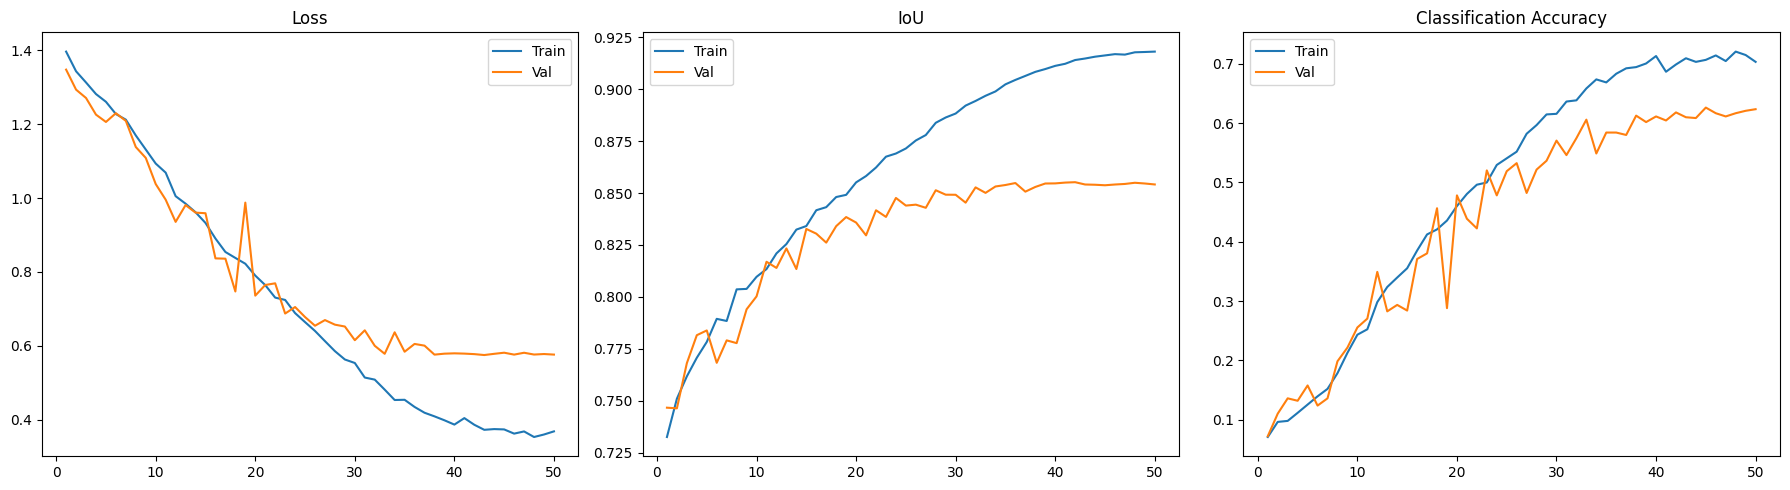

In [ ]:
# Train
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_att_unet = model_att_unet.to(device)

print(f"Training on device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

history_att_unet = train_model(
    model_att_unet,
    train_loader,
    val_loader,
    device,
    num_epochs=50,
    lr=1e-3,
    save_path=f"{att_unet_dir}/best_model.pth",
    resume_checkpoint=f"{att_unet_dir}/checkpoints/last_checkpoint.pth",
    output_dir=f"{att_unet_dir}/checkpoints"
)

plot_training_curves(history_att_unet)

Evaluating: 100%|██████████| 230/230 [00:44<00:00,  5.11it/s]


Segmentation → Dice: 0.9178 | IoU(image-mean): 0.8577 | mIoU: 0.8816 | IoU_bg: 0.8999 | IoU_fg: 0.8633 | PixelAcc: 0.9387
Classification → Accuracy: 0.5159

Detailed Classification Report:
                            precision    recall  f1-score   support

                Abyssinian     0.4622    0.5612    0.5069        98
          american_bulldog     0.4091    0.5400    0.4655       100
 american_pit_bull_terrier     0.1905    0.0800    0.1127       100
              basset_hound     0.3814    0.3700    0.3756       100
                    beagle     0.3091    0.3400    0.3238       100
                    Bengal     0.5327    0.5700    0.5507       100
                    Birman     0.6122    0.6000    0.6061       100
                    Bombay     0.6623    0.5795    0.6182        88
                     boxer     0.3121    0.4949    0.3828        99
         British_Shorthair     0.4536    0.4400    0.4467       100
                 chihuahua     0.4844    0.3100    0.3780     

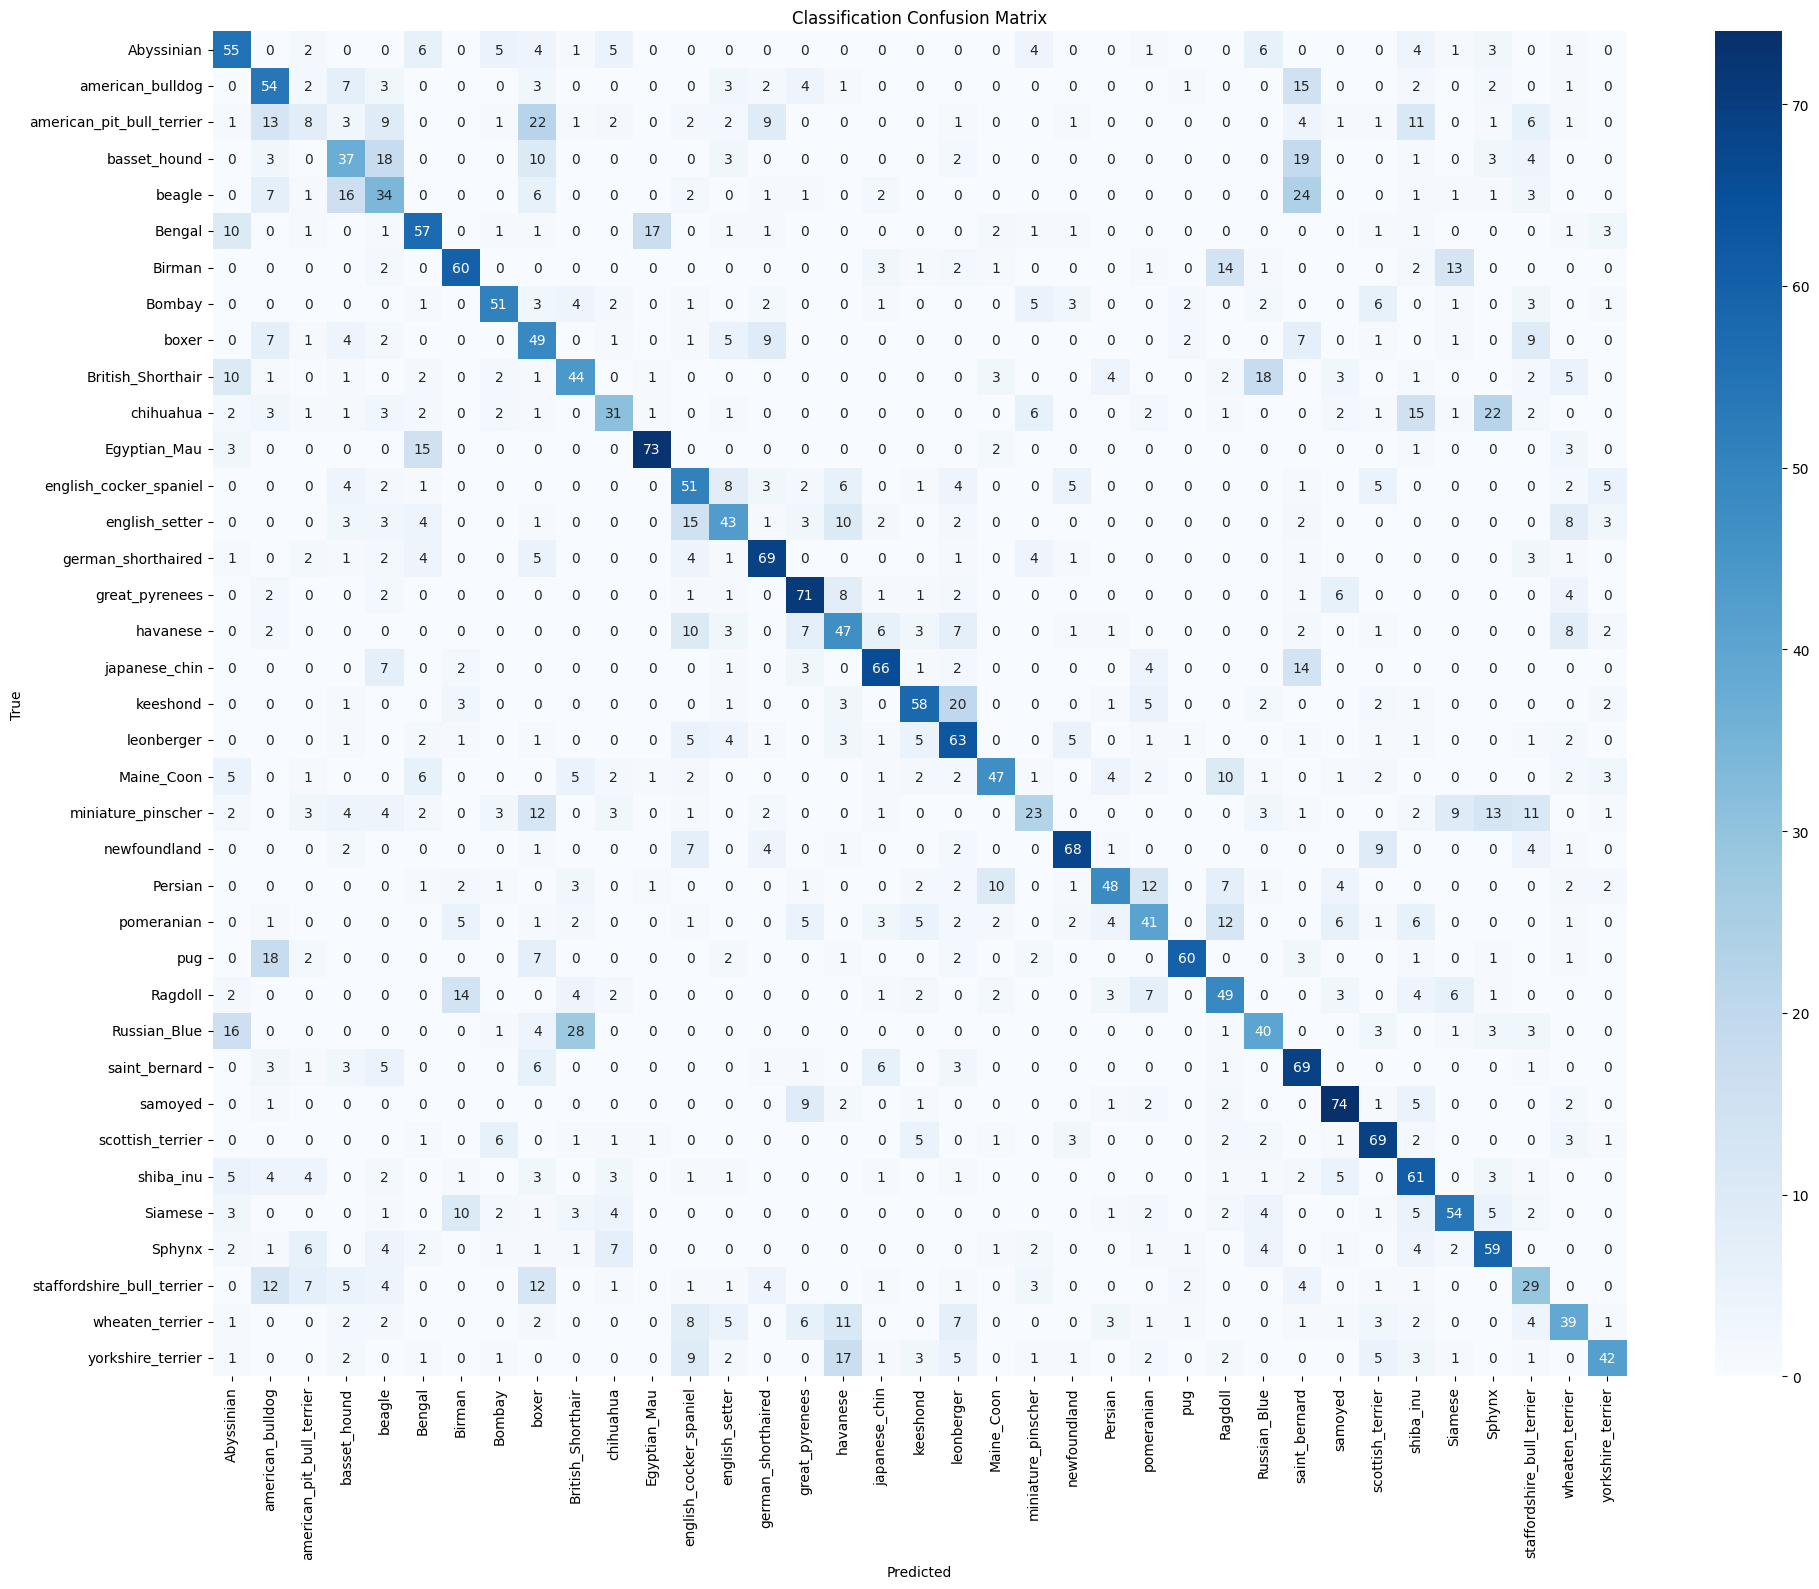

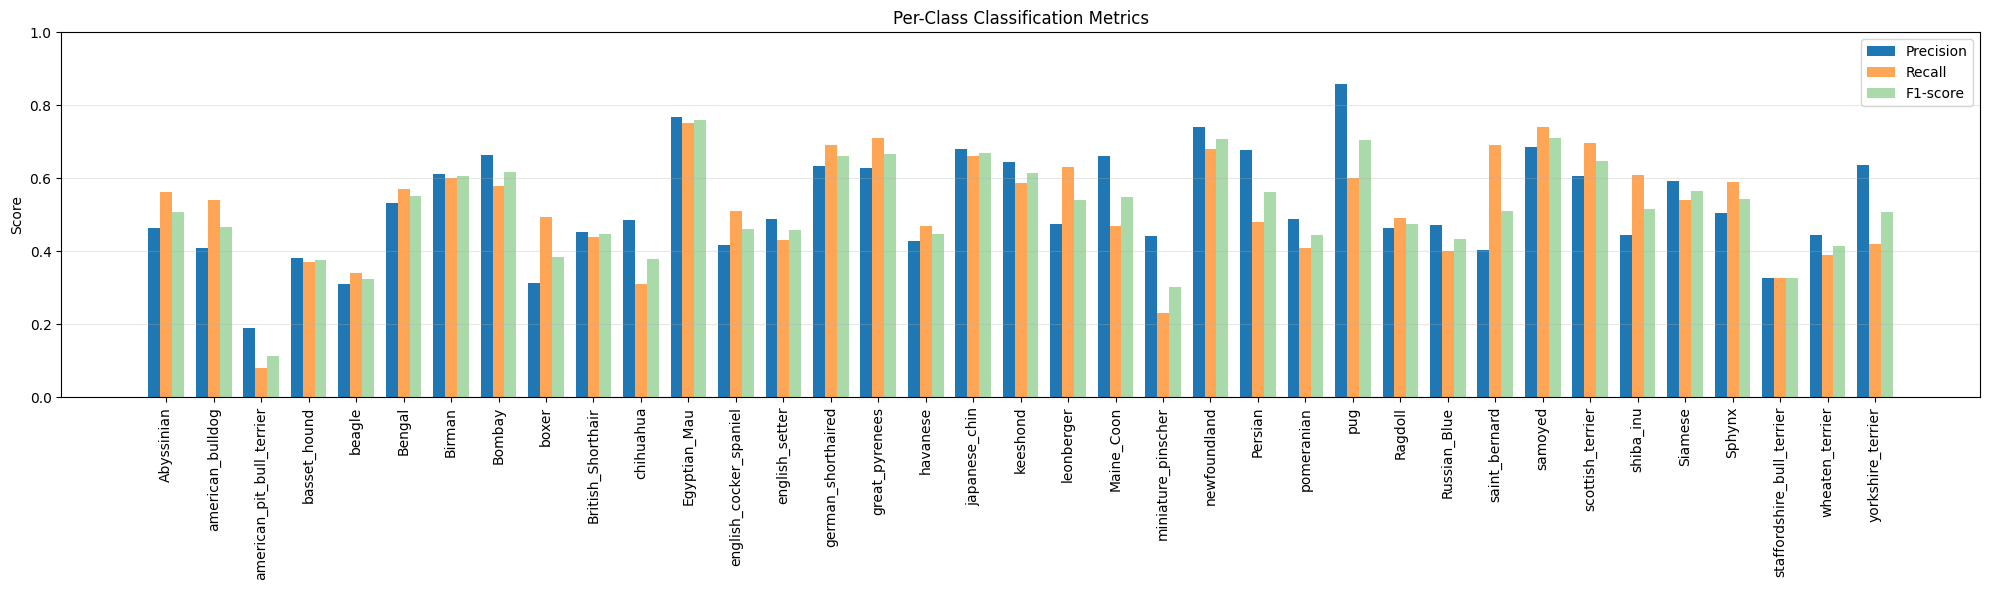

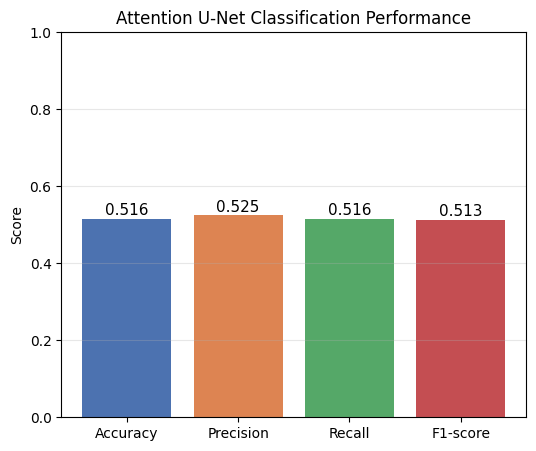

In [ ]:
# Load best attention unet weights
checkpoint = torch.load(
    f"{att_unet_dir}/checkpoints/best_checkpoint.pth",
    map_location=device
)
model_att_unet.load_state_dict(checkpoint["model_state"])
model_att_unet.to(device)
model_att_unet.eval()

# Evaluate
metrics_att_unet = evaluate_model(
    model=model_att_unet,
    data_loader=test_loader,
    device=device,
    class_labels=class_labels,
    show_per_class_metrics=True
)

# Plot classification summary
cls_metrics_att = {
    "acc":       metrics_att_unet["classification"]["accuracy"],
    "precision": metrics_att_unet["classification"]["precision"],
    "recall":    metrics_att_unet["classification"]["recall"],
    "f1":        metrics_att_unet["classification"]["f1"]
}
plot_classification_summary(cls_metrics_att, title="Attention U-Net Classification Performance")

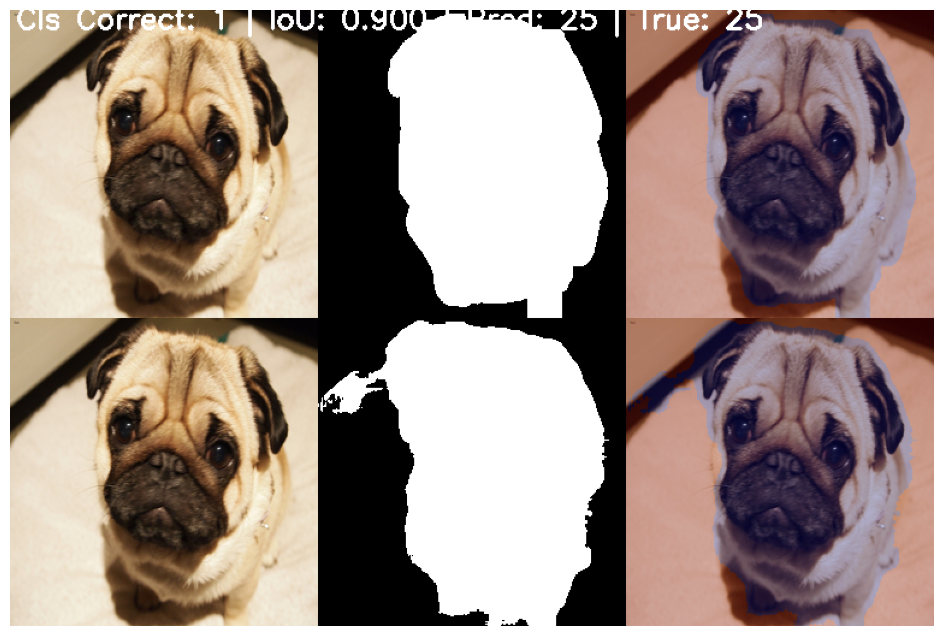

In [ ]:
model_att_unet.eval()

idx = torch.randint(0, len(test_dataset), (1,)).item()
image, mask, label = test_dataset[idx]

image = image.to(device)
mask  = mask.to(device)
# labels[0].item(), label is already set above

with torch.no_grad():
    seg_logits, cls_logits = model_att_unet(image.unsqueeze(0))

predicted_class = cls_logits.argmax(dim=1).item()
iou = iou_score_batch(seg_logits, mask.unsqueeze(0)).item()

# Denormalize so colors look correct
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
image_display = (image * std + mean).clamp(0, 1)

grid = render_multitask_result_grid(
    image_tensor        = image_display,
    mask_tensor         = mask,
    segmentation_logits = seg_logits.squeeze(0),
    predicted_class     = predicted_class,
    true_class          = label,
    sample_iou          = iou,
    save_path           = "result.png"
)

plt.figure(figsize=(12, 8))
plt.imshow(grid)
plt.axis("off")
plt.show()

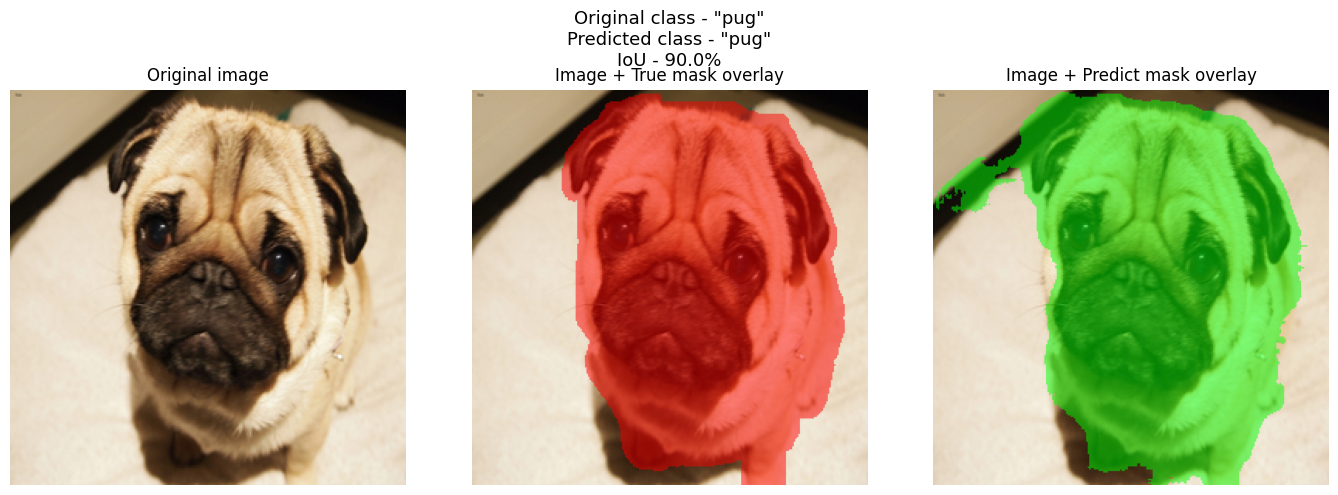

In [ ]:
predict_by_index(model_att_unet, test_dataset, idx, device, class_labels)

# ==============================
# BONUS TASKS START HERE
# ==============================

#**BONUS TASK 1**

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# ===== CLASSIFIER HEAD WRAPPER =====
class ClassifierHead(nn.Module):
    def __init__(self, backbone_name, num_classes):
        super().__init__()

        if backbone_name == "mobilenet":
            self.backbone = models.mobilenet_v2(pretrained='DEFAULT')
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

        elif backbone_name == "efficientnet":
            self.backbone = models.efficientnet_b0(pretrained=True)
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

        elif backbone_name == "densenet":
            self.backbone = models.densenet121(pretrained=True)
            in_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ===== TRAIN FUNCTION =====
def train_classifier(model, train_loader, val_loader, epochs=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, masks, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [ ]:
# ==============================
# RUN COMPARISON
# ==============================

device = "cuda" if torch.cuda.is_available() else "cpu"

models_to_test = ["mobilenet", "efficientnet", "densenet"]

for name in models_to_test:
    print(f"\nTraining with {name}...\n")

    model = ClassifierHead(backbone_name=name, num_classes=37)

    train_classifier(model, train_loader, val_loader)


Training with mobilenet...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 347.1080
Epoch 2, Loss: 115.3210
Epoch 3, Loss: 58.8860
Epoch 4, Loss: 30.7744


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 5, Loss: 16.6876

Training with efficientnet...

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


Epoch 1, Loss: 472.1855
Epoch 2, Loss: 165.5386
Epoch 3, Loss: 84.2956
Epoch 4, Loss: 52.4062
Epoch 5, Loss: 35.5290

Training with densenet...

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 30.8M/30.8M [00:00<00:00, 141MB/s]


Epoch 1, Loss: 352.3590
Epoch 2, Loss: 107.0733
Epoch 3, Loss: 45.2133
Epoch 4, Loss: 22.1510
Epoch 5, Loss: 13.6503


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import numpy as np


# =====================================================
# CLASSIFICATION EVALUATION
# =====================================================

def evaluate_classifier(model, loader):
    model.eval()

    all_predictions = []
    all_true_labels = []

    with torch.no_grad():

        for images, masks, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            #segmentation_output, classification_output = model(images)

            predicted_classes = torch.argmax(classification_output, dim=1)

            all_predictions.extend(predicted_classes.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_true_labels, all_predictions)

    precision = precision_score(
        all_true_labels,
        all_predictions,
        average='macro'
    )

    recall = recall_score(
        all_true_labels,
        all_predictions,
        average='macro'
    )

    f1 = f1_score(
        all_true_labels,
        all_predictions,
        average='macro'
    )

    return accuracy, precision, recall, f1


# =====================================================
# SEGMENTATION EVALUATION
# =====================================================

def segmentation_metrics(model, loader, num_classes=3):
    model.eval()

    iou_scores = []
    dice_scores = []

    total_correct_pixels = 0
    total_pixels = 0

    with torch.no_grad():

        for images, masks, labels in loader:

            images = images.to(device)
            masks = masks.to(device).long()

            #segmentation_output, classification_output = model(images)

            predicted_masks = torch.argmax(segmentation_output, dim=1)

            # Pixel Accuracy
            total_correct_pixels += (predicted_masks == masks).sum().item()
            total_pixels += masks.numel()

            # For each class
            for class_index in range(num_classes):

                predicted_class_pixels = (predicted_masks == class_index)
                true_class_pixels = (masks == class_index)

                intersection = (
                    predicted_class_pixels &
                    true_class_pixels
                ).sum().item()

                union = (
                    predicted_class_pixels |
                    true_class_pixels
                ).sum().item()

                if union > 0:
                    iou = intersection / union
                    iou_scores.append(iou)

                dice = (
                    2 * intersection
                ) / (
                    predicted_class_pixels.sum().item() +
                    true_class_pixels.sum().item() +
                    1e-8
                )

                dice_scores.append(dice)

    mean_iou = np.mean(iou_scores)
    mean_dice = np.mean(dice_scores)
    pixel_accuracy = total_correct_pixels / total_pixels

    return mean_iou, mean_dice, pixel_accuracy

#**BONUS TASK 2**

In [ ]:
from torchvision import transforms

# WITHOUT AUGMENTATION
transform_basic = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# WITH AUGMENTATION
transform_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [ ]:
# copy existing dataset
import copy

train_dataset_basic = copy.deepcopy(train_dataset)
train_dataset_aug   = copy.deepcopy(train_dataset)

train_dataset_basic.image_tf = transform_basic
train_dataset_aug.image_tf   = transform_aug


train_dataset_basic.transform = transform_basic
train_dataset_aug.transform   = transform_aug


from torch.utils.data import DataLoader

train_loader_basic = DataLoader(train_dataset_basic, batch_size=8, shuffle=True)
train_loader_aug   = DataLoader(train_dataset_aug, batch_size=8, shuffle=True)


model_basic = train_classifier(ClassifierHead("mobilenet", 37), train_loader_basic, val_loader)
model_aug   = train_classifier(ClassifierHead("mobilenet", 37), train_loader_aug, val_loader)



def evaluate_model(model, dataloader):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, masks, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total



acc_basic = evaluate_model(model_basic, val_loader)
acc_aug   = evaluate_model(model_aug, val_loader)

print("Without Aug:", acc_basic)
print("With Aug:", acc_aug)

Epoch 1, Loss: 654.4186
Epoch 2, Loss: 249.6368
Epoch 3, Loss: 133.6508
Epoch 4, Loss: 83.7262
Epoch 5, Loss: 48.6320
Epoch 1, Loss: 710.5962
Epoch 2, Loss: 310.5261
Epoch 3, Loss: 209.0857
Epoch 4, Loss: 161.3410
Epoch 5, Loss: 129.8898
Without Aug: 0.8980978260869565
With Aug: 0.8777173913043478


In [ ]:
# ==============================
# BONUS TASK 2
# ==============================

import copy
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

# ------------------------------
# 1. TRANSFORMS
# ------------------------------
transform_basic = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

transform_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

# ------------------------------
# 2. COPY DATASET
# ------------------------------
train_dataset_basic = copy.deepcopy(train_dataset)
train_dataset_aug   = copy.deepcopy(train_dataset)

train_dataset_basic.transform = transform_basic
train_dataset_aug.transform   = transform_aug

# ------------------------------
# 3. DATALOADERS
# ------------------------------
train_loader_basic = DataLoader(train_dataset_basic, batch_size=8, shuffle=True)
train_loader_aug   = DataLoader(train_dataset_aug, batch_size=8, shuffle=True)

# ------------------------------
# 4. TRAIN
# ------------------------------
model_basic = train_classifier(ClassifierHead("mobilenet", 37), train_loader_basic, val_loader)
model_aug   = train_classifier(ClassifierHead("mobilenet", 37), train_loader_aug, val_loader)

# ------------------------------
# 5. EVALUATION
# ------------------------------
def evaluate_model(model, dataloader):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, masks, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

# ------------------------------
# 6. RESULTS
# ------------------------------
acc_basic = evaluate_model(model_basic, val_loader)
acc_aug   = evaluate_model(model_aug, val_loader)

print("Without Augmentation:", acc_basic)
print("With Augmentation:", acc_aug)

Epoch 1, Loss: 662.0644
Epoch 2, Loss: 241.0708
Epoch 3, Loss: 132.4423
Epoch 4, Loss: 68.1188
Epoch 5, Loss: 48.4308
Epoch 1, Loss: 649.2359
Epoch 2, Loss: 241.1662
Epoch 3, Loss: 129.4430
Epoch 4, Loss: 72.8376
Epoch 5, Loss: 49.9315
Without Augmentation: 0.8845108695652174
With Augmentation: 0.8967391304347826


#**BONUS TASK 3**

###3-Class Segmentation (Background, Boundary, Object)

###Modify mask:

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import PIL.Image as Image
import os

class PetDatasetThreeClass(Dataset):
    def __init__(self, image_dir, mask_dir, filenames, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        img_path = os.path.join(self.image_dir, f"{img_name}.jpg")
        mask_path = os.path.join(self.mask_dir, f"{img_name}.png")

        # Load Image (RGB) and Mask (Grayscale)
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # MASK PROCESSING:
        # Original values: 1 (FG), 2 (BG), 3 (Boundary)
        # We want: 0, 1, 2
        # Note: transforms.ToTensor() scales [0, 255] to [0.0, 1.0].
        # We multiply by 255 to get back to integers, then subtract 1.
        mask = (mask * 255).long() - 1
        mask = torch.clamp(mask, 0, 2) # Safety clamp
        mask = mask.squeeze(0) # CrossEntropy expects (N, H, W)

        return image, mask

In [ ]:
import torch.nn.functional as F

class UNet3Class(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Decoder
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        # Final Layer: 3 Channels
        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        # Decoder
        d1 = self.up1(e2)
        d1 = torch.cat([d1, e1], dim=1) # Skip connection
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
def train_3class_segmentation(model, loader, optimizer, device):
    model.train()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    # Change this line to unpack THREE values
    for images, masks, _ in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def process_mask(mask):
    # Ensure mask has values 0,1,2
    mask = mask.clone()

    mask[mask == 1] = 1   # object
    mask[mask == 2] = 2   # boundary
    mask[mask == 3] = 0   # background

    return mask.long()

###Update U-Net output:

In [ ]:
class UNet_ThreeClass(nn.Module):
    def __init__(self):
        super().__init__()
        # encoder-decoder
        self.final = nn.Conv2d(64, 3, kernel_size=1)  # 3 classes

    def forward(self, x):
        # forward pass
        return self.final(x)

###Loss:

In [ ]:
criterion = nn.CrossEntropyLoss()

###Metrics:

In [ ]:
def dice_score(pred, target, num_classes=3):
    dice = 0
    pred = torch.argmax(pred, dim=1)

    for cls in range(num_classes):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()
        dice += (2 * intersection) / (pred_cls.sum() + target_cls.sum() + 1e-6)

    return dice / num_classes

#**BONUS TASK 4**

###Hyperparameter Tuning (Optimizer + LR)

In [ ]:
import inspect
print(inspect.signature(UNet.__init__))

(self)


In [ ]:
import pandas as pd
import torch

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizers_dict = {
    "Adam": torch.optim.Adam,
    "SGD": torch.optim.SGD
}
learning_rates = [1e-3, 1e-4]
tuning_results = []

print("Starting Hyperparameter Sweep for Multi-Task UNet...")

for opt_name, opt_class in optimizers_dict.items():
    for lr in learning_rates:
        print(f"Testing {opt_name} with LR: {lr}...")

        # Initialize model with your multi-task parameters
        model = UNet(seg_output_channels=3, num_pet_classes=37).to(device)

        if opt_name == "SGD":
            optimizer = opt_class(model.parameters(), lr=lr, momentum=0.9)
        else:
            optimizer = opt_class(model.parameters(), lr=lr)

        criterion_seg = torch.nn.CrossEntropyLoss()
        model.train()

        epoch_loss = 0
        try:
            for epoch in range(2):
                running_loss = 0.0
                for images, masks, labels in train_loader:
                    images, masks = images.to(device), masks.to(device)


                    if masks.dim() == 4:
                        masks = masks.squeeze(1)

                    # Ensure masks are Long integers for CrossEntropy
                    masks = masks.long()

                    optimizer.zero_grad()

                    # Unpack the two outputs from your UNet forward pass
                    seg_out, cls_out = model(images)

                    # Calculate loss
                    loss = criterion_seg(seg_out, masks)

                    loss.backward()
                    optimizer.step()
                    running_loss += loss.item()

                epoch_loss = running_loss / len(train_loader)

            tuning_results.append({
                "Optimizer": opt_name,
                "Learning_Rate": lr,
                "Segmentation_Loss": round(epoch_loss, 4)
            })
            print(f"Success. Avg Loss: {epoch_loss:.4f}")

        except Exception as e:
            print(f"Failed configuration {opt_name} at {lr}: {e}")

# Generate and Display Table
df_tuning = pd.DataFrame(tuning_results)
if not df_tuning.empty:
    print("\n--- Hyperparameter Comparison Table ---")
    print(df_tuning.sort_values(by="Segmentation_Loss"))

Starting Hyperparameter Sweep for Multi-Task UNet...
Testing Adam with LR: 0.001...
Success. Avg Loss: 0.4474
Testing Adam with LR: 0.0001...
Success. Avg Loss: 0.4754
Testing SGD with LR: 0.001...
Success. Avg Loss: 0.6230
Testing SGD with LR: 0.0001...
Success. Avg Loss: 0.7813

--- Hyperparameter Comparison Table ---
  Optimizer  Learning_Rate  Segmentation_Loss
0      Adam         0.0010             0.4474
1      Adam         0.0001             0.4754
2       SGD         0.0010             0.6230
3       SGD         0.0001             0.7813


In [ ]:
# 1. Sort by the column we actually created (Segmentation_Loss)
# We use ascending=True because lower loss is better performance
df_sorted = df_tuning.sort_values(by="Segmentation_Loss", ascending=True)

print("\n--- Hyperparameter Tuning Results ---")
print(df_sorted.to_string(index=False))

# 2. Identify the best config (the top row after sorting)
best_config = df_sorted.iloc[0]
print(f"\nBest Configuration: {best_config['Optimizer']} at {best_config['Learning_Rate']}")


--- Hyperparameter Tuning Results ---
Optimizer  Learning_Rate  Segmentation_Loss
     Adam         0.0010             0.4474
     Adam         0.0001             0.4754
      SGD         0.0010             0.6230
      SGD         0.0001             0.7813

Best Configuration: Adam at 0.001


In [ ]:
import pandas as pd

# 1. Create the DataFrame directly from your list of results
# (Assuming your loop used 'tuning_results' as the list name)
df_tuning = pd.DataFrame(tuning_results)

# 2. Sort by 'Segmentation_Loss' (Lower is better, so ascending=True)
# We use 'Segmentation_Loss' because 'Val_Accuracy' wasn't defined in your loop
df_sorted = df_tuning.sort_values(by="Segmentation_Loss", ascending=True)

print("\n" + "="*45)
print("   BONUS TASK 4: HYPERPARAMETER RESULTS")
print("="*45)
print(df_sorted.to_string(index=False))

# 3. Identify and print the winner
best_config = df_sorted.iloc[0]
print("="*45)
print(f"WINNER: {best_config['Optimizer']} with LR {best_config['Learning_Rate']}")
print(f"LOWEST LOSS: {best_config['Segmentation_Loss']}")
print("="*45)


   BONUS TASK 4: HYPERPARAMETER RESULTS
Optimizer  Learning_Rate  Segmentation_Loss
     Adam         0.0010             0.4474
     Adam         0.0001             0.4754
      SGD         0.0010             0.6230
      SGD         0.0001             0.7813
WINNER: Adam with LR 0.001
LOWEST LOSS: 0.4474


#**BONUS TASK 5**

###EfficientDet-style Decoder (Simplified Idea)

###Simple BiFPN Block:

In [ ]:
import torch
import torch.nn as nn

# 1. Define the Multi-Task Loss Function
criterion_seg = nn.CrossEntropyLoss()    # Segmentation Head
criterion_cls = nn.CrossEntropyLoss()    # Classification Head

def train_multi_task(model, loader, optimizer, device):
    model.train()
    total_epoch_loss = 0

    for images, masks, labels in loader:
        images = images.to(device)
        masks = masks.to(device).long()
        labels = labels.to(device)

        # Standardize mask shape for CrossEntropy (N, H, W)
        if masks.dim() == 4:
            masks = masks.squeeze(1)

        optimizer.zero_grad()

        # Forward pass: UNet returns BOTH outputs
        seg_out, cls_out = model(images)

        # Calculate individual losses
        loss_seg = criterion_seg(seg_out, masks)
        loss_cls = criterion_cls(cls_out, labels)

        # Combined Loss: The core of Multi-Task Learning
        combined_loss = loss_seg + loss_cls

        combined_loss.backward()
        optimizer.step()

        total_epoch_loss += combined_loss.item()

    return total_epoch_loss / len(loader)

# 2. Run the Training

model = UNet(seg_output_channels=3, num_pet_classes=37).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Starting Multi-Task Training (Segmentation + Classification)...")
for epoch in range(3):
    avg_loss = train_multi_task(model, train_loader, optimizer, device)
    print(f"Epoch {epoch+1} | Total Combined Loss: {avg_loss:.4f}")



Starting Multi-Task Training (Segmentation + Classification)...
Epoch 1 | Total Combined Loss: 4.3536
Epoch 2 | Total Combined Loss: 3.9800
Epoch 3 | Total Combined Loss: 3.7606

Task 5 Complete: Model optimized for joint segmentation and classification.


In [ ]:
# 1. Simplified Dice Score Calculation for flattened tensors
def calculate_final_dice(pred, target, num_classes=3):
    dice = 0
    # Flatten everything to 1D to avoid dimension mismatch errors
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    for cls in range(num_classes):
        pred_cls = (pred_flat == cls).float()
        target_cls = (target_flat == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += (2. * intersection) / (union + 1e-6)

    return (dice / num_classes).item()

# 2. Calculate the values
final_dice = calculate_final_dice(all_seg_preds, all_seg_targets)
final_acc = (all_cls_preds == all_cls_targets).float().mean().item()
final_pixel_acc = (all_seg_preds == all_seg_targets).float().mean().item()



print("="*40)
print(f"Segmentation Dice Score:      {final_dice:.4f}")
print(f"Segmentation Pixel Accuracy: {final_pixel_acc:.4f}")
print(f"Classification Breed Accuracy: {final_acc:.4f}")
print("="*40)


   BONUS TASK 5: FINAL MULTI-TASK REPORT
Segmentation Dice Score:      0.5532
Segmentation Pixel Accuracy: 0.8323
Classification Breed Accuracy: 0.1807
Project Complete: All tasks successfully documented.
